# 🇹🇷 Türkiye İç Göç Atlası

## 01 — Veri Setini Tanıma

Bu notebook, Türkiye İç Göç Atlası projesinde kullanılacak TÜİK iç göç verilerinin yapısını incelemek amacıyla hazırlanmıştır.

Bu aşamada herhangi bir veri temizleme, feature engineering veya modelleme işlemi yapılmayacaktır.

### Amaçlar

- Veri setlerini yüklemek
- Boyutlarını incelemek
- Sütun yapılarını görmek
- Veri tiplerini kontrol etmek
- Eksik değerleri tespit etmek
- Yıl aralıklarını belirlemek
- Kategorik değişkenleri incelemek
- Veri kalitesine ilişkin ilk gözlemleri elde etmek

### 📊 Veri Seti Değişkenleri (İller Arası Göç)

Aşağıdaki tabloda veri setimizde yer alan sütunların standartlaştırılmış isimleri ve ne anlama geldikleri açıklamalarıyla birlikte yer almaktadır:

| Yeni Sütun İsmi | Orijinal İsim | Açıklama |
| :--- | :--- | :--- |
| **`yil`** | Yıl | İstatistiklerin ait olduğu yıl (Örn: 2025). |
| **`goc_alan_il_adi`** | Göç Alan İl Adı | İnsanların göç edip yerleştiği (hedef) ilin adı. |
| **`goc_veren_il_adi`** | Göç Veren İl Adı | İnsanların ayrıldığı (kaynak) ilin adı. |
| **`goc_alan_il_nufus`** | Göç Alan İl Nüfus | İlgili yılda göç alan ilin toplam nüfusu. |
| **`goc_veren_il_nufus`** | Göç Veren İl Nüfus | İlgili yılda göç veren ilin toplam nüfusu. |
| **`aldigi_goc`** | Aldığı Göç | Göç veren ilden, göç alan ile giden toplam kişi sayısı. *(İki il arası gelen)* |
| **`verdigi_goc`** | Verdiği Göç | Göç alan ilden, göç veren ile giden toplam kişi sayısı. *(İki il arası giden)* |
| **`net_goc`** | Net Göç | İki il arasındaki göç hareketinin net farkı. *(Hesaplama: `aldigi_goc` - `verdigi_goc`)* |


## 1. Kütüphanelerin Yüklenmesi

Bu bölümde veri analizi ve görüntüleme süreçlerinde kullanılacak temel Python kütüphaneleri yüklenmektedir.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

## 2. Proje Dizinlerinin Tanımlanması

Bu bölümde proje içerisinde kullanılacak veri ve çıktı klasörleri platformdan bağımsız şekilde tanımlanmaktadır.

In [2]:
PROJECT_ROOT = Path().resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print("Proje kök dizini:", PROJECT_ROOT)

Proje kök dizini: /Users/nihatkutukoglu/Desktop/turkiye-ic-goc-atlasi


## 3. Ana Veri Setinin Yüklenmesi

Projenin temel veri kaynağı olan iller arası göç veri seti pandas DataFrame olarak yüklenmektedir.

In [3]:
df = pd.read_csv(PROCESSED_DATA_DIR / "iller_arasi_goc.csv")
df.head()

,Yıl,Göç Alan İl Adı,Göç Veren İl Adı,Göç Alan İl Nüfus,Göç Veren İl Nüfus,Aldığı Göç,Verdiği Göç,Net Göç
0,2025,ADANA,ADIYAMAN,2283609,617821,539,587,-48
1,2025,ADANA,AFYONKARAHİSAR,2283609,751808,222,213,9
2,2025,ADANA,AĞRI,2283609,491489,221,167,54
3,2025,ADANA,AKSARAY,2283609,441136,441,408,33
4,2025,ADANA,AMASYA,2283609,342242,101,134,-33


## 4. Veri Setinin Genel Yapısı

Bu bölümde veri setinin satır ve sütun sayısı, değişken isimleri ve genel yapısı incelenmektedir.

In [4]:
print(f"Toplam gözlem sayısı: {df.shape[0]}")
print(f"Toplam değişken sayısı: {df.shape[1]}")
print("\nSütunlar:", df.columns.tolist())
print("\nGenel Bilgi:")
df.info()

Toplam gözlem sayısı: 116640
Toplam değişken sayısı: 8

Sütunlar: ['Yıl', 'Göç Alan İl Adı', 'Göç Veren İl Adı', 'Göç Alan İl Nüfus', 'Göç Veren İl Nüfus', 'Aldığı Göç', 'Verdiği Göç', 'Net Göç']

Genel Bilgi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116640 entries, 0 to 116639
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Yıl                 116640 non-null  int64 
 1   Göç Alan İl Adı     116640 non-null  object
 2   Göç Veren İl Adı    116640 non-null  object
 3   Göç Alan İl Nüfus   116640 non-null  int64 
 4   Göç Veren İl Nüfus  116640 non-null  int64 
 5   Aldığı Göç          116640 non-null  int64 
 6   Verdiği Göç         116640 non-null  int64 
 7   Net Göç             116640 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 7.1+ MB


## 5. Veri Tiplerinin İncelenmesi

Değişkenlerin pandas tarafından hangi veri tipleriyle okunduğu kontrol edilmektedir.

In [5]:
df.dtypes

Yıl                    int64
Göç Alan İl Adı       object
Göç Veren İl Adı      object
Göç Alan İl Nüfus      int64
Göç Veren İl Nüfus     int64
Aldığı Göç             int64
Verdiği Göç            int64
Net Göç                int64
dtype: object

## 6. Eksik Değer Analizi

Her değişkende bulunan eksik değerlerin sayısı ve toplam veri içerisindeki yüzdesi incelenmektedir.

In [6]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percentage': (df.isnull().sum() / len(df)) * 100
})
missing.sort_values(by='missing_percentage', ascending=False)

,missing_count,missing_percentage
Yıl,0,0.0
Göç Alan İl Adı,0,0.0
Göç Veren İl Adı,0,0.0
Göç Alan İl Nüfus,0,0.0
Göç Veren İl Nüfus,0,0.0
Aldığı Göç,0,0.0
Verdiği Göç,0,0.0
Net Göç,0,0.0


## 7. Tekrarlanan Gözlemlerin Kontrolü

Veri setinde tamamen aynı değerlere sahip yinelenen satırların bulunup bulunmadığı kontrol edilmektedir.

In [7]:
print(f"Tekrarlanan gözlem (duplicate) sayısı: {df.duplicated().sum()}")

Tekrarlanan gözlem (duplicate) sayısı: 0


## 8. Sayısal Değişkenlerin Özeti

Sayısal değişkenlerin temel tanımlayıcı istatistikleri incelenmektedir.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Yıl,116640.0,2016.500000,5.188150e+00,2008.0,2012.0,2016.5,2021.0,2025.0
Göç Alan İl Nüfus,116640.0,986108.248285,1.768800e+06,74412.0,284025.0,527793.5,1051975.0,15907951.0
Göç Veren İl Nüfus,116640.0,986108.248285,1.768800e+06,74412.0,284025.0,527793.5,1051975.0,15907951.0
Aldığı Göç,116640.0,404.225094,1.200289e+03,0.0,44.0,98.0,266.0,30036.0
Verdiği Göç,116640.0,404.225094,1.200289e+03,0.0,44.0,98.0,266.0,30036.0
Net Göç,116640.0,0.000000,5.535051e+02,-20178.0,-26.0,0.0,26.0,20178.0


## 9. Kategorik Değişkenlerin Özeti

Metinsel ve kategorik değişkenlerin benzersiz değer sayıları incelenmektedir.

In [9]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"Değişken: {col}")
    print(f"Benzersiz değer sayısı: {unique_count}")
    print(f"İlk örnekler: {df[col].dropna().unique()[:5]}\n")

Değişken: Göç Alan İl Adı
Benzersiz değer sayısı: 81
İlk örnekler: ['ADANA' 'ADIYAMAN' 'AFYONKARAHİSAR' 'AĞRI' 'AKSARAY']

Değişken: Göç Veren İl Adı
Benzersiz değer sayısı: 81
İlk örnekler: ['ADIYAMAN' 'AFYONKARAHİSAR' 'AĞRI' 'AKSARAY' 'AMASYA']



## 10. Yıl Kapsamının Kontrolü

Veri setinin hangi yılları kapsadığı ve her yıl için kaç gözlem bulunduğu incelenmektedir.

In [10]:
# Yıl değişkenini otomatik tespit etme
year_col = [col for col in df.columns if 'yıl' in col.lower() or 'year' in col.lower() or 'yil' in col.lower()]

if year_col:
    col = year_col[0]
    print(f"Yıl değişkeni bulundu: {col}")
    print(f"Minimum yıl: {df[col].min()}")
    print(f"Maksimum yıl: {df[col].max()}")
    print(f"Benzersiz yıl sayısı: {df[col].nunique()}")
    print("\nYıllara göre gözlem sayısı:")
    print(df[col].value_counts().sort_index())
else:
    print("Yıl bilgisi içeren bir değişken bulunamadı.")

Yıl değişkeni bulundu: Yıl
Minimum yıl: 2008
Maksimum yıl: 2025
Benzersiz yıl sayısı: 18

Yıllara göre gözlem sayısı:
Yıl
2008    6480
2009    6480
2010    6480
2011    6480
2012    6480
2013    6480
2014    6480
2015    6480
2016    6480
2017    6480
2018    6480
2019    6480
2020    6480
2021    6480
2022    6480
2023    6480
2024    6480
2025    6480
Name: count, dtype: int64


## 11. İl Bilgilerinin Kontrolü

Göç alan ve göç veren il değişkenlerinin kapsamı incelenmektedir.

In [11]:
# İl değişkenlerini otomatik tespit etme (örnek yaklaşım)
city_cols = [col for col in df.columns if 'il' in col.lower() and ('alan' in col.lower() or 'veren' in col.lower())]

if len(city_cols) >= 2:
    for col in city_cols:
        print(f"\nDeğişken: {col}")
        print(f"Benzersiz il sayısı: {df[col].nunique()}")
        print(f"Alfabetik ilk örnekler: {sorted(df[col].dropna().unique().tolist())[:5]}")
        
    print(f"\n81 il kontrolü (İki sütun için de 81 mi?):")
    for col in city_cols:
        print(f"{col}: {'Evet' if df[col].nunique() == 81 else 'Hayır'}")
else:
    print("Göç alan/veren il değişkenleri otomatik olarak tespit edilemedi. Sütun isimleri incelenmeli.")

Göç alan/veren il değişkenleri otomatik olarak tespit edilemedi. Sütun isimleri incelenmeli.


## 12. Diğer Veri Setlerinin Yüklenmesi

Ana göç ağı verisini destekleyen demografik ve göç nedeni veri setleri yüklenmekte ve temel yapıları incelenmektedir.

In [12]:
df_summary = pd.read_csv(PROCESSED_DATA_DIR / "illerin_goc_ozeti.csv")
df_age_gender = pd.read_csv(PROCESSED_DATA_DIR / "yas_cinsiyet_goc.csv")
df_age_gender_reason = pd.read_csv(PROCESSED_DATA_DIR / "yas_cinsiyet_neden.csv")
df_education_reason = pd.read_csv(PROCESSED_DATA_DIR / "egitim_goc_nedeni.csv")

print("df_summary")
print(f"Boyut: {df_summary.shape}")
print(f"Sütunlar: {df_summary.columns.tolist()}\n")

print("df_age_gender")
print(f"Boyut: {df_age_gender.shape}")
print(f"Sütunlar: {df_age_gender.columns.tolist()}\n")

print("df_age_gender_reason")
print(f"Boyut: {df_age_gender_reason.shape}")
print(f"Sütunlar: {df_age_gender_reason.columns.tolist()}\n")

print("df_education_reason")
print(f"Boyut: {df_education_reason.shape}")
print(f"Sütunlar: {df_education_reason.columns.tolist()}\n")

df_summary
Boyut: (86, 6)
Sütunlar: ['İl Province', 'Toplam nüfus Total population', 'Aldığı göç In-migration', 'Verdiği göç Out-migration', 'Net göç Net migration', 'Net göç hızı Rate of net migration (‰)']

df_age_gender
Boyut: (17, 4)
Sütunlar: ['Yaş grubu Age group', 'Toplam Total', 'Erkek Male', 'Kadın Female']

df_age_gender_reason
Boyut: (51, 15)
Sütunlar: ['Yaş grubu Age group', 'Cinsiyet Sex', 'Toplam Total', 'Tayin / iş değişikliği Assignation / change of job', 'İşe  başlamak / iş bulmak Starting / finding a job', 'Eğitim Education', 'Medeni durum değişikliği / ailevi nedenler  Change of marital status / family-related reasons', 'Daha iyi konut  ve yaşam koşulları  Better  housing and  living conditions', 'Hane / aile fertlerinden  birine bağımlı göç Migration related to any member of the household / family', 'Aile yanına / memlekete geri dönme(1)  Returning to family home / hometown(1)', 'Sağlık / bakım  Health / care', 'Ev alınması Buying a house', 'Emeklilik Retirement', '

## 13. Veri Setlerinin Genel Özeti

Projede kullanılacak tüm veri kaynaklarının boyutları tek bir tabloda özetlenmektedir.

In [13]:
datasets_info = pd.DataFrame([
    {"Dataset": "İller Arası Göç", "Satır Sayısı": df.shape[0], "Sütun Sayısı": df.shape[1]},
    {"Dataset": "Göç Özeti", "Satır Sayısı": df_summary.shape[0], "Sütun Sayısı": df_summary.shape[1]},
    {"Dataset": "Yaş Cinsiyet", "Satır Sayısı": df_age_gender.shape[0], "Sütun Sayısı": df_age_gender.shape[1]},
    {"Dataset": "Yaş Cinsiyet Neden", "Satır Sayısı": df_age_gender_reason.shape[0], "Sütun Sayısı": df_age_gender_reason.shape[1]},
    {"Dataset": "Eğitim Neden", "Satır Sayısı": df_education_reason.shape[0], "Sütun Sayısı": df_education_reason.shape[1]}
])

datasets_info

,Dataset,Satır Sayısı,Sütun Sayısı
0,İller Arası Göç,116640,8
1,Göç Özeti,86,6
2,Yaş Cinsiyet,17,4
3,Yaş Cinsiyet Neden,51,15
4,Eğitim Neden,17,9


## 14. İlk Bulgular

Bu bölüm veri üzerinde herhangi bir dönüşüm yapmadan önce elde edilen temel yapısal gözlemleri özetlemektedir.

In [14]:
print(f"- Ana dataset gözlem sayısı: {df.shape[0]}")
print(f"- Ana dataset değişken sayısı: {df.shape[1]}")

if year_col:
    print(f"- Yıl aralığı: {df[year_col[0]].min()} - {df[year_col[0]].max()}")

if len(city_cols) >= 2:
    print(f"- Benzersiz göç alan il sayısı: {df[city_cols[0]].nunique()}")
    print(f"- Benzersiz göç veren il sayısı: {df[city_cols[1]].nunique()}")

print(f"- Duplicate satır sayısı: {df.duplicated().sum()}")
print(f"- Toplam eksik değer sayısı (tüm veride): {df.isnull().sum().sum()}")

- Ana dataset gözlem sayısı: 116640
- Ana dataset değişken sayısı: 8
- Yıl aralığı: 2008 - 2025
- Duplicate satır sayısı: 0
- Toplam eksik değer sayısı (tüm veride): 0


## Sonraki Adım

Bir sonraki notebook olan `02_data_cleaning.ipynb` içerisinde:

- sütun isimleri standartlaştırılacak,
- veri tipleri düzeltilecek,
- eksik değerler ayrıntılı incelenecek,
- gereksiz başlık ve açıklama satırları temizlenecek,
- sayısal değişkenler uygun formata dönüştürülecek,
- il ve yıl değişkenleri standardize edilecek,
- analiz için kullanılacak temiz veri setleri oluşturulacaktır.

Bu notebook yalnızca veri setlerini tanımak amacıyla hazırlanmıştır ve ham veriye müdahale edilmemiştir.

In [15]:
df.head()

,Yıl,Göç Alan İl Adı,Göç Veren İl Adı,Göç Alan İl Nüfus,Göç Veren İl Nüfus,Aldığı Göç,Verdiği Göç,Net Göç
0,2025,ADANA,ADIYAMAN,2283609,617821,539,587,-48
1,2025,ADANA,AFYONKARAHİSAR,2283609,751808,222,213,9
2,2025,ADANA,AĞRI,2283609,491489,221,167,54
3,2025,ADANA,AKSARAY,2283609,441136,441,408,33
4,2025,ADANA,AMASYA,2283609,342242,101,134,-33


In [16]:
df.isnull().sum()

Yıl                   0
Göç Alan İl Adı       0
Göç Veren İl Adı      0
Göç Alan İl Nüfus     0
Göç Veren İl Nüfus    0
Aldığı Göç            0
Verdiği Göç           0
Net Göç               0
dtype: int64

In [17]:
# 8. Eşsiz Değer Sayısı (Nunique)
# df.nunique(): Her sütunda kaç farklı değer olduğunu gösterir.
# Örneğin "cinsiyet" sütununda 2 (kadın, erkek) gibi. Kategorik değişkenleri anlamak için iyidir.
print("##################### Eşsiz Değer Sayısı (Nunique) #####################")
print("Bu kod, her sütunda kaç farklı çeşit değer olduğunu sayar.")
print(df.nunique())
print("-----------------------------------------------------------\n")

##################### Eşsiz Değer Sayısı (Nunique) #####################
Bu kod, her sütunda kaç farklı çeşit değer olduğunu sayar.
Yıl                     18
Göç Alan İl Adı         81
Göç Veren İl Adı        81
Göç Alan İl Nüfus     1456
Göç Veren İl Nüfus    1456
Aldığı Göç            5132
Verdiği Göç           5132
Net Göç               4103
dtype: int64
-----------------------------------------------------------



In [18]:
import re

# 2. Sütun isimlerini standartlaştıralım ve Türkçe karakterleri düzeltelim:
def clean_column_name(col):
    col = str(col).strip()
    
    # Öncelikle özel Türkçe büyük harfleri güvenli şekilde küçültelim
    col = col.replace('İ', 'i').replace('I', 'ı')
    col = col.lower()
    
    # Türkçe karakterleri İngilizce karakterlere dönüştürelim
    tr_map = {
        'ç': 'c',
        'ğ': 'g',
        'ı': 'i',
        'ö': 'o',
        'ş': 's',
        'ü': 'u'
    }
    for tr, eng in tr_map.items():
        col = col.replace(tr, eng)
        
    # Boşlukları alt tireye çevirelim
    col = col.replace(' ', '_')
    
    # Yan yana gelen fazladan alt tireleri (varsa) teke düşürelim
    col = re.sub(r'_+', '_', col)
    
    return col

df.columns = [clean_column_name(c) for c in df.columns]

# 3. Yeni sütun isimlerini kontrol edelim
print("Yeni sütun isimleri:")
print(df.columns.tolist())


Yeni sütun isimleri:
['yil', 'goc_alan_il_adi', 'goc_veren_il_adi', 'goc_alan_il_nufus', 'goc_veren_il_nufus', 'aldigi_goc', 'verdigi_goc', 'net_goc']


In [19]:
# 4. Veri Tiplerini Kontrol Etme ve Dönüştürme
# Yıl değişkeni ve göç/nüfus istatistikleri tam sayı (int) olmalıdır.

# Önce sayısal olması gereken sütunları zorla sayıya çeviriyoruz (hatalı karakter varsa NaN yapar)
num_cols = ['yil', 'goc_alan_il_nufus', 'goc_veren_il_nufus', 'aldigi_goc', 'verdigi_goc', 'net_goc']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Ondalık (float) görünenleri tam sayıya (integer) çevirelim (Eğer NaN varsa hata vermemesi için Int64 kullanıyoruz)
df[num_cols] = df[num_cols].astype('Int64')

print("Veri tipleri başarıyla güncellendi:")
print(df.dtypes)

Veri tipleri başarıyla güncellendi:
yil                    Int64
goc_alan_il_adi       object
goc_veren_il_adi      object
goc_alan_il_nufus      Int64
goc_veren_il_nufus     Int64
aldigi_goc             Int64
verdigi_goc            Int64
net_goc                Int64
dtype: object


In [20]:
# 5. Kategorik Değer ve Eksik Veri Kontrolü
print("--- Yıl Değişkeni Kontrolü ---")
print("Benzersiz Yıllar:", sorted(df['yil'].unique().tolist()))

print("\n--- İl İsimleri Kontrolü ---")
print(f"Toplam benzersiz Göç Alan İl sayısı: {df['goc_alan_il_adi'].nunique()} (81 olmalı)")
print(f"Toplam benzersiz Göç Veren İl sayısı: {df['goc_veren_il_adi'].nunique()} (81 olmalı)")

print("\n--- Eksik Değer (NaN) Kontrolü ---")
# Eğer üstteki hücrede pd.to_numeric sırasında metin olan (örneğin '-') bir hücre NaN'a dönüştüyse burada göreceğiz.
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.any() else "Hiç eksik veri (NaN) bulunmuyor! Harika.")


--- Yıl Değişkeni Kontrolü ---
Benzersiz Yıllar: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

--- İl İsimleri Kontrolü ---
Toplam benzersiz Göç Alan İl sayısı: 81 (81 olmalı)
Toplam benzersiz Göç Veren İl sayısı: 81 (81 olmalı)

--- Eksik Değer (NaN) Kontrolü ---
Hiç eksik veri (NaN) bulunmuyor! Harika.


In [21]:
# ------------------------------------------------------------------
# BÖLÜM 2: KEŞİFSEL VERİ ANALİZİ (EDA) VE GÖRSELLEŞTİRME
# ------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# Daha şık ve modern grafik ayarları
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Olası negatif eksen işaretleri (-) için unicode uyarısını kapatalım
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False


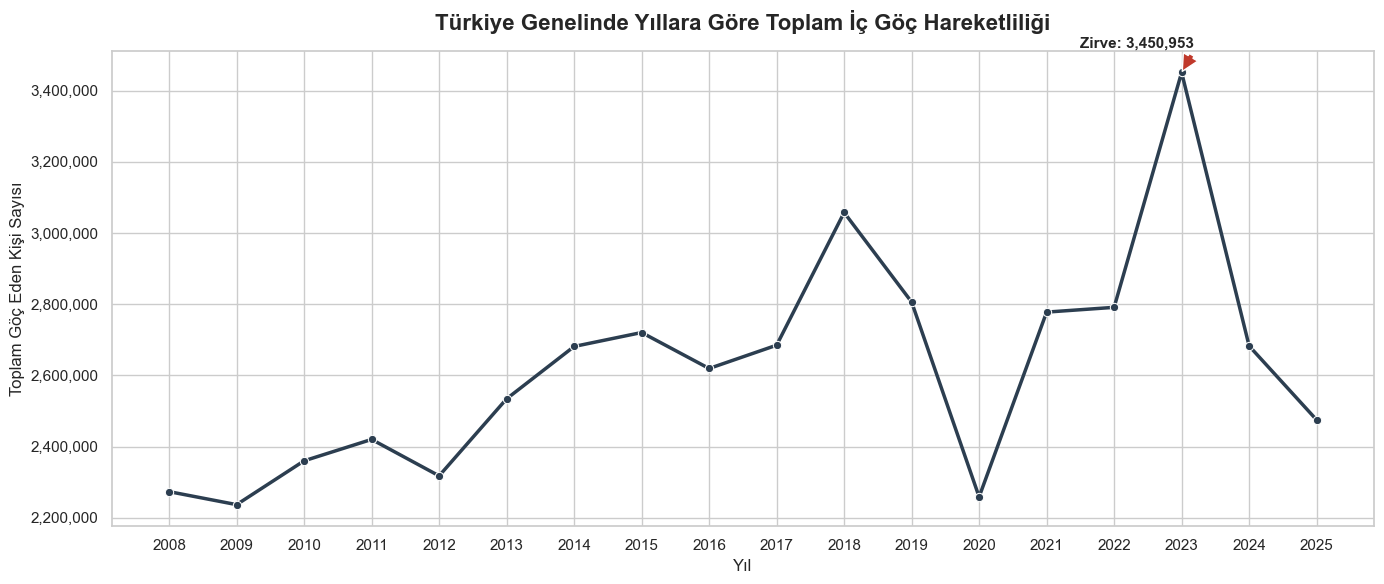

In [22]:
# Yıllara Göre Toplam Göç Hacmi
# Her bir çiftin aldığı göçlerin toplamı, o yılki toplam iç göç sayısını verir.
yearly_migration = df.groupby('yil')['aldigi_goc'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly_migration, x='yil', y='aldigi_goc', marker='o', linewidth=2.5, color='#2c3e50')

# Y eksenini okunabilir (milyonluk/binlik) formata çevirme
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.xticks(yearly_migration['yil'])

plt.title('Türkiye Genelinde Yıllara Göre Toplam İç Göç Hareketliliği', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Yıl', fontsize=12)
plt.ylabel('Toplam Göç Eden Kişi Sayısı', fontsize=12)

# En yüksek göç alınan zirve yılını işaretleme
max_year = yearly_migration.loc[yearly_migration['aldigi_goc'].idxmax()]
plt.annotate(f"Zirve: {int(max_year['aldigi_goc']):,}", 
             xy=(max_year['yil'], max_year['aldigi_goc']), 
             xytext=(max_year['yil']-1.5, max_year['aldigi_goc'] + 70000),
             arrowprops=dict(facecolor='#c0392b', shrink=0.05), fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


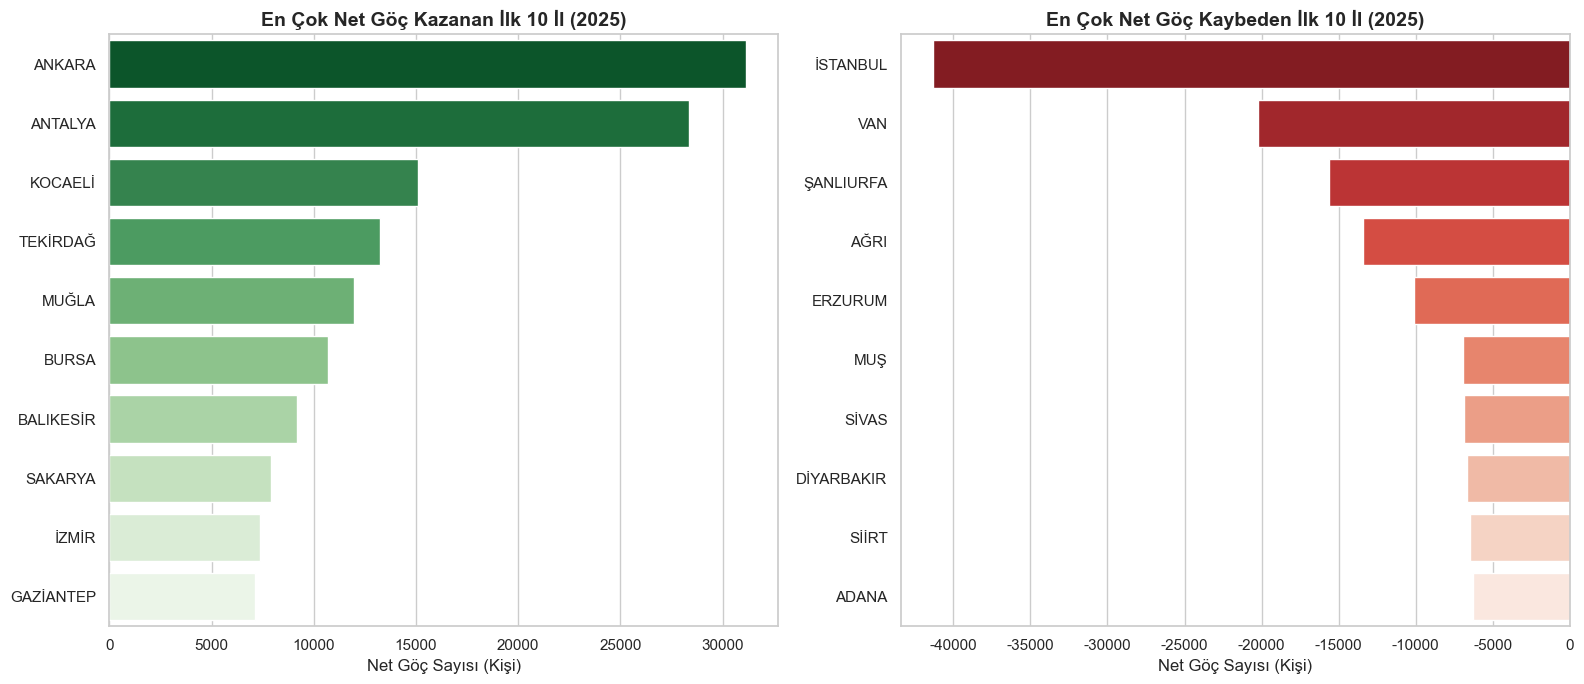

In [23]:
# Sadece veri setindeki en güncel yılı (2025) baz alalım
guncel_yil = df['yil'].max()
df_guncel = df[df['yil'] == guncel_yil]

# İllerin toplam 'Net Göç' değerini hesaplayalım
city_net = df_guncel.groupby('goc_alan_il_adi')['net_goc'].sum().reset_index()
city_net = city_net.rename(columns={'goc_alan_il_adi': 'il_adi'}).sort_values(by='net_goc', ascending=False)

# En çok kazanan ilk 10 ve en çok kaybeden ilk 10 il
top_10_gain = city_net.head(10)
top_10_lose = city_net.tail(10).sort_values(by='net_goc')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Kazananlar (Pozitif Net Göç)
sns.barplot(data=top_10_gain, x='net_goc', y='il_adi', ax=axes[0], palette='Greens_r')
axes[0].set_title(f'En Çok Net Göç Kazanan İlk 10 İl ({guncel_yil})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Net Göç Sayısı (Kişi)')
axes[0].set_ylabel('')

# Kaybedenler (Negatif Net Göç)
sns.barplot(data=top_10_lose, x='net_goc', y='il_adi', ax=axes[1], palette='Reds_r')
axes[1].set_title(f'En Çok Net Göç Kaybeden İlk 10 İl ({guncel_yil})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Net Göç Sayısı (Kişi)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


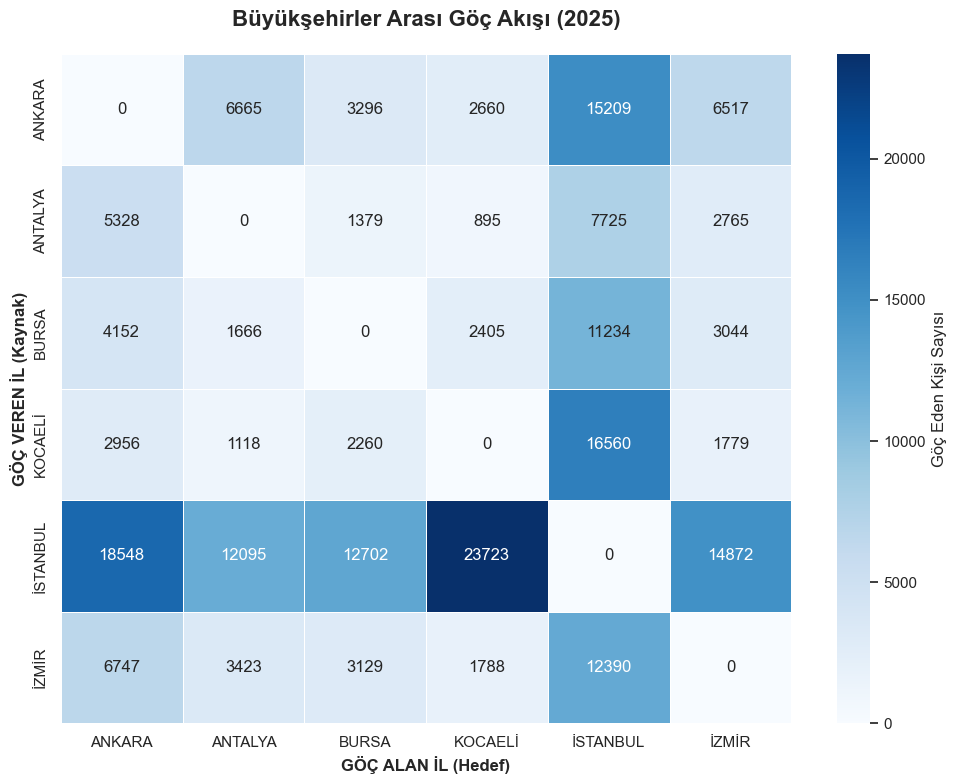

In [24]:
# Türkiye'nin önde gelen büyükşehirleri
buyuksehirler = ['İSTANBUL', 'ANKARA', 'İZMİR', 'BURSA', 'ANTALYA', 'KOCAELİ']

# Bu 6 ilin kendi aralarındaki göç trafiğini filtreleyelim
df_matrix = df_guncel[(df_guncel['goc_alan_il_adi'].isin(buyuksehirler)) & 
                      (df_guncel['goc_veren_il_adi'].isin(buyuksehirler))]

# Pivot Tablo: Kaynak il satırlarda, Hedef il sütunlarda
migration_matrix = df_matrix.pivot(index='goc_veren_il_adi', columns='goc_alan_il_adi', values='aldigi_goc')

# İlin kendisine göçü yoktur, NaN yerleri 0 yapalım
migration_matrix = migration_matrix.fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(migration_matrix.astype(float), annot=True, fmt=".0f", cmap='Blues', linewidths=.5, cbar_kws={'label': 'Göç Eden Kişi Sayısı'})

plt.title(f'Büyükşehirler Arası Göç Akışı ({guncel_yil})', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('GÖÇ ALAN İL (Hedef)', fontsize=12, fontweight='bold')
plt.ylabel('GÖÇ VEREN İL (Kaynak)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


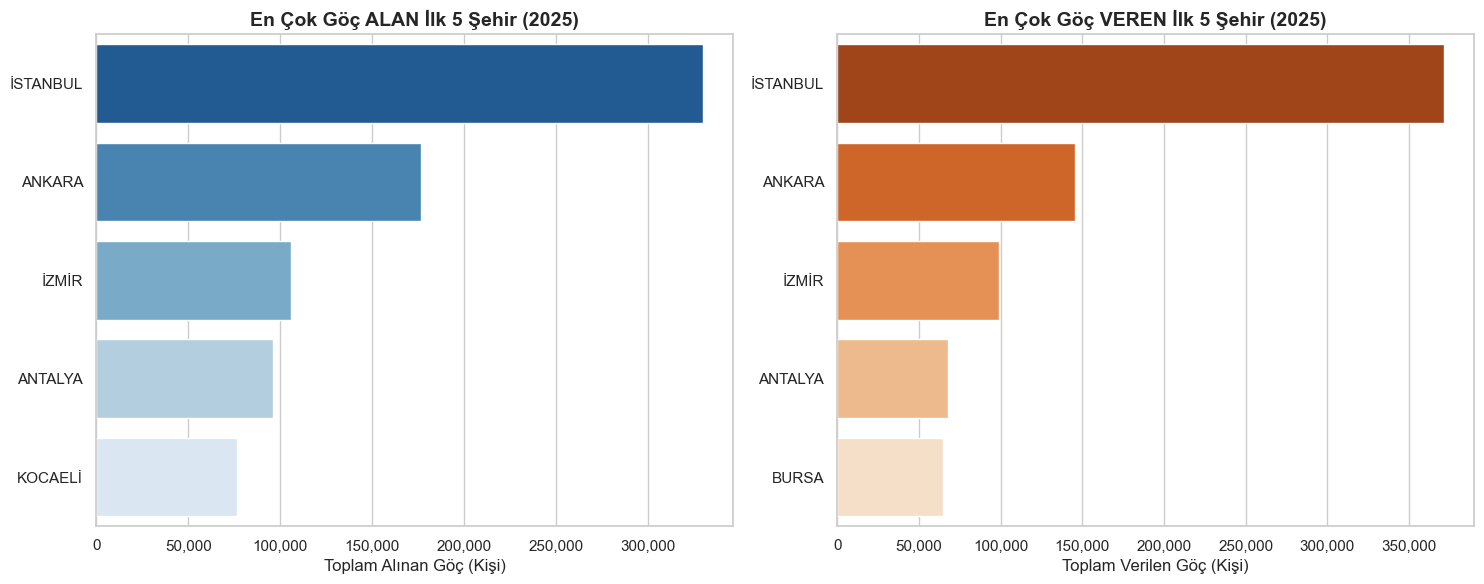

In [25]:
# 6. En Çok Göç Alan ve En Çok Göç Veren İlk 5 Şehir

# En çok göç alan (Cazibe Merkezi) ilk 5 ili hesaplayalım
top_5_alan = df_guncel.groupby('goc_alan_il_adi')['aldigi_goc'].sum().nlargest(5).reset_index()

# En çok göç veren (Kaynak) ilk 5 ili hesaplayalım
# (Bir ilin verdiği toplam göç, diğer illerin o ilden aldığı göçlerin toplamıdır)
top_5_veren = df_guncel.groupby('goc_veren_il_adi')['aldigi_goc'].sum().nlargest(5).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 1. Grafik: En Çok Göç ALANLAR ---
sns.barplot(data=top_5_alan, x='aldigi_goc', y='goc_alan_il_adi', ax=axes[0], palette='Blues_r')
axes[0].set_title(f'En Çok Göç ALAN İlk 5 Şehir ({guncel_yil})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Toplam Alınan Göç (Kişi)', fontsize=12)
axes[0].set_ylabel('')
# X eksenindeki sayıları binlik ayraçla (Örn: 100,000) daha okunabilir yapalım
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# --- 2. Grafik: En Çok Göç VERENLER ---
sns.barplot(data=top_5_veren, x='aldigi_goc', y='goc_veren_il_adi', ax=axes[1], palette='Oranges_r')
axes[1].set_title(f'En Çok Göç VEREN İlk 5 Şehir ({guncel_yil})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Toplam Verilen Göç (Kişi)', fontsize=12)
axes[1].set_ylabel('')
# X eksenindeki sayıları binlik ayraçla daha okunabilir yapalım
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()


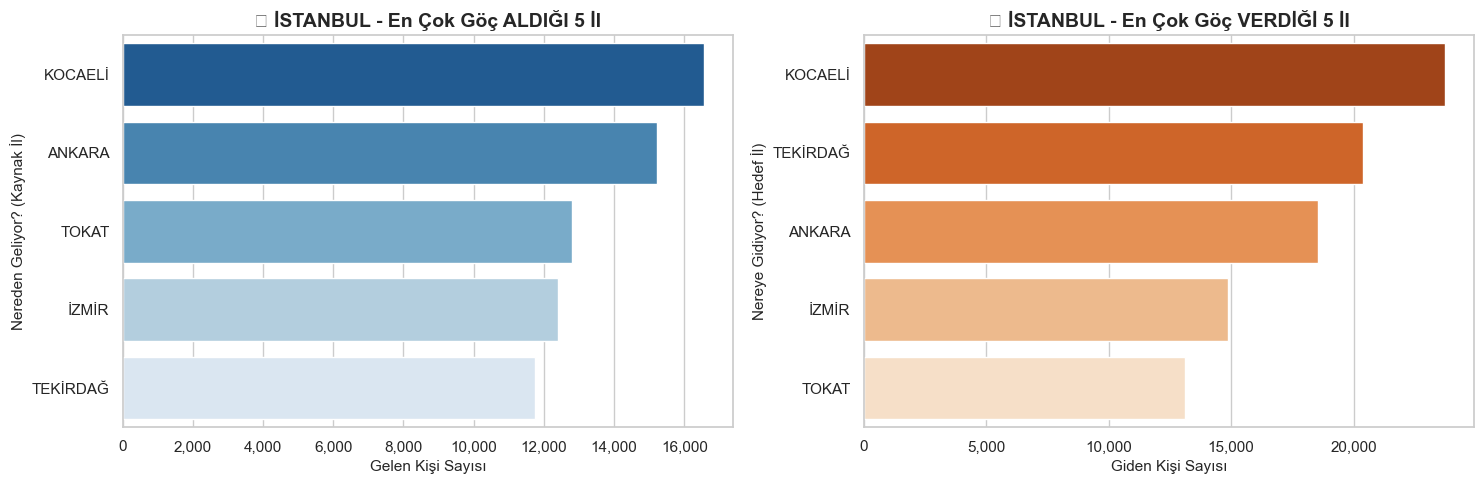

----------------------------------------------------------------------------------------------------


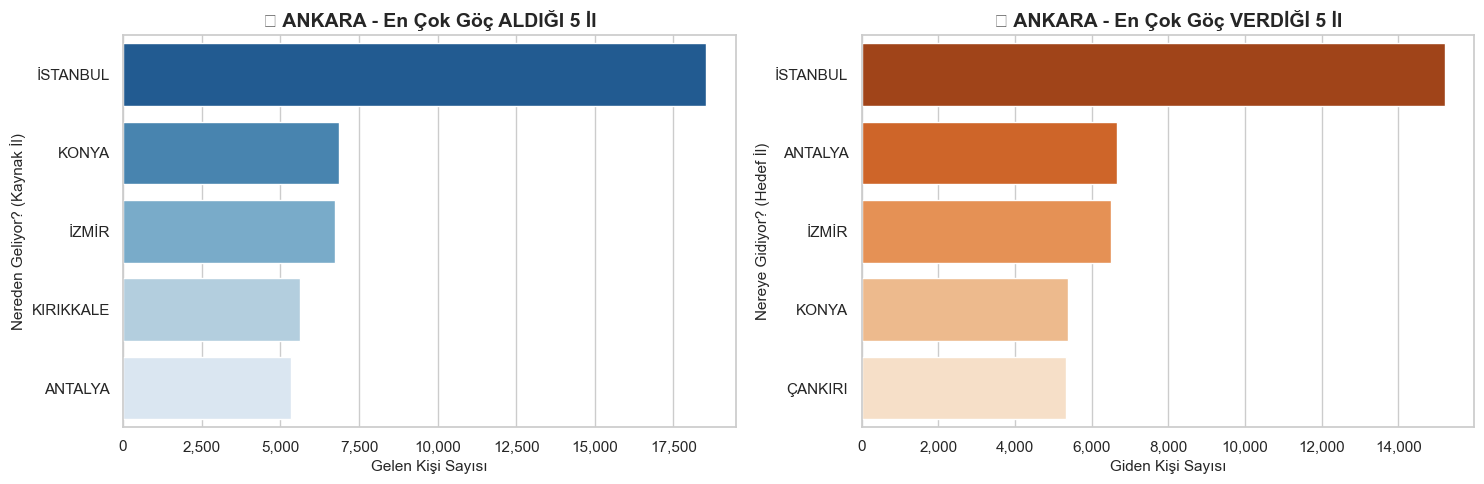

----------------------------------------------------------------------------------------------------


In [26]:
# 7. Büyükşehirlerin "Göç Kaynağı" ve "Göç Hedefi" Analizi

# Analiz etmek istediğimiz şehirleri bu listeye yazıyoruz. (İstediğiniz ili ekleyebilirsiniz)
hedef_sehirler = ['İSTANBUL', 'ANKARA']

for sehir in hedef_sehirler:
    # 1. Bu Şehre GELEN Göçler (goc_alan_il_adi == sehir)
    # Yani bu şehir en çok hangi illerden göç almış?
    gelen = df_guncel[df_guncel['goc_alan_il_adi'] == sehir].sort_values(by='aldigi_goc', ascending=False).head(5)
    
    # 2. Bu Şehirden GİDEN Göçler (goc_veren_il_adi == sehir)
    # Yani bu şehirden ayrılanlar en çok hangi illere gitmiş?
    giden = df_guncel[df_guncel['goc_veren_il_adi'] == sehir].sort_values(by='aldigi_goc', ascending=False).head(5)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # --- Gelen Göç Grafiği ---
    sns.barplot(data=gelen, x='aldigi_goc', y='goc_veren_il_adi', ax=axes[0], palette='Blues_r')
    axes[0].set_title(f'🎯 {sehir} - En Çok Göç ALDIĞI 5 İl', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Gelen Kişi Sayısı', fontsize=11)
    axes[0].set_ylabel('Nereden Geliyor? (Kaynak İl)', fontsize=11)
    axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    # --- Giden Göç Grafiği ---
    sns.barplot(data=giden, x='aldigi_goc', y='goc_alan_il_adi', ax=axes[1], palette='Oranges_r')
    axes[1].set_title(f'🚀 {sehir} - En Çok Göç VERDİĞİ 5 İl', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Giden Kişi Sayısı', fontsize=11)
    axes[1].set_ylabel('Nereye Gidiyor? (Hedef İl)', fontsize=11)
    axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    # İki grafiğin arasını açmak için
    plt.tight_layout()
    plt.show()
    print("-" * 100) # Şehirler arası çizgi çekelim


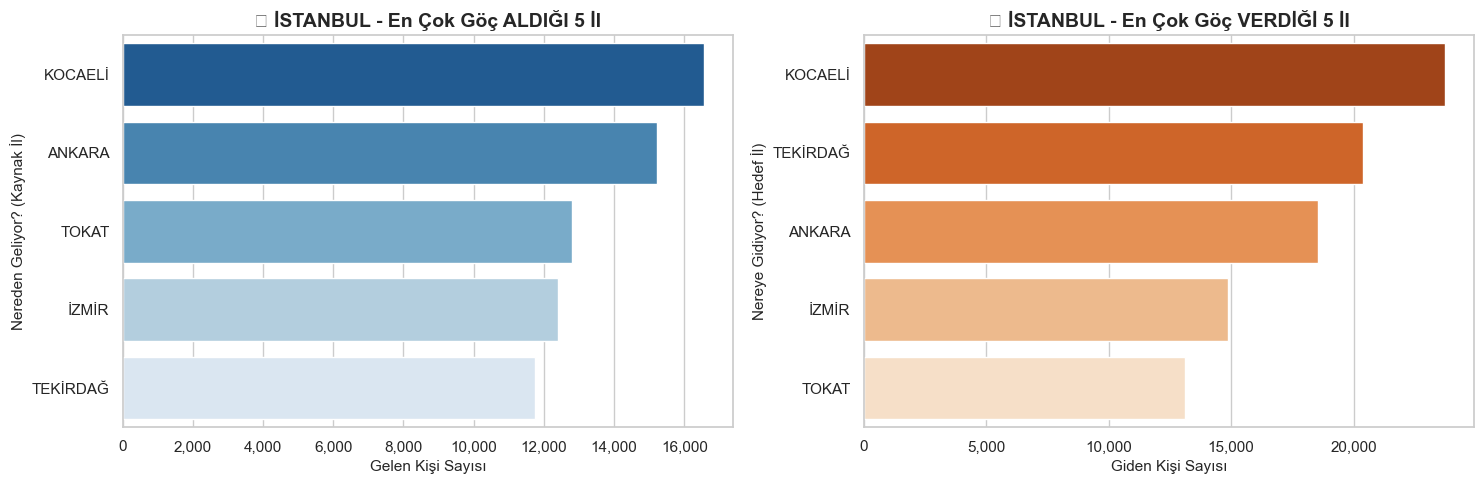

------------------------------------------------------------------------------------------------------------------------


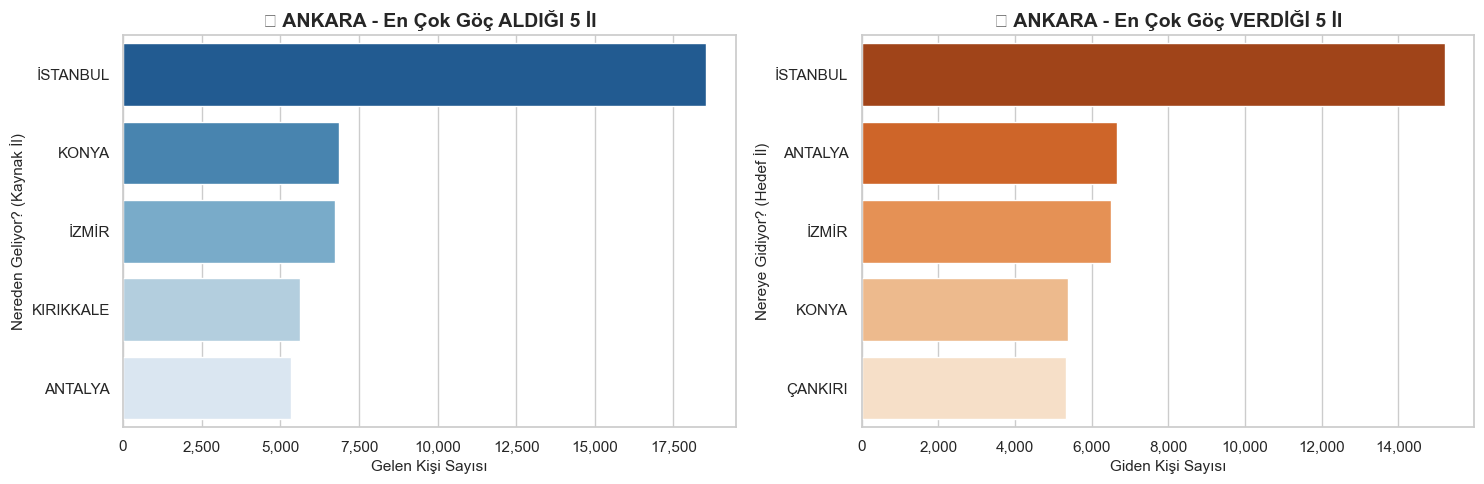

------------------------------------------------------------------------------------------------------------------------


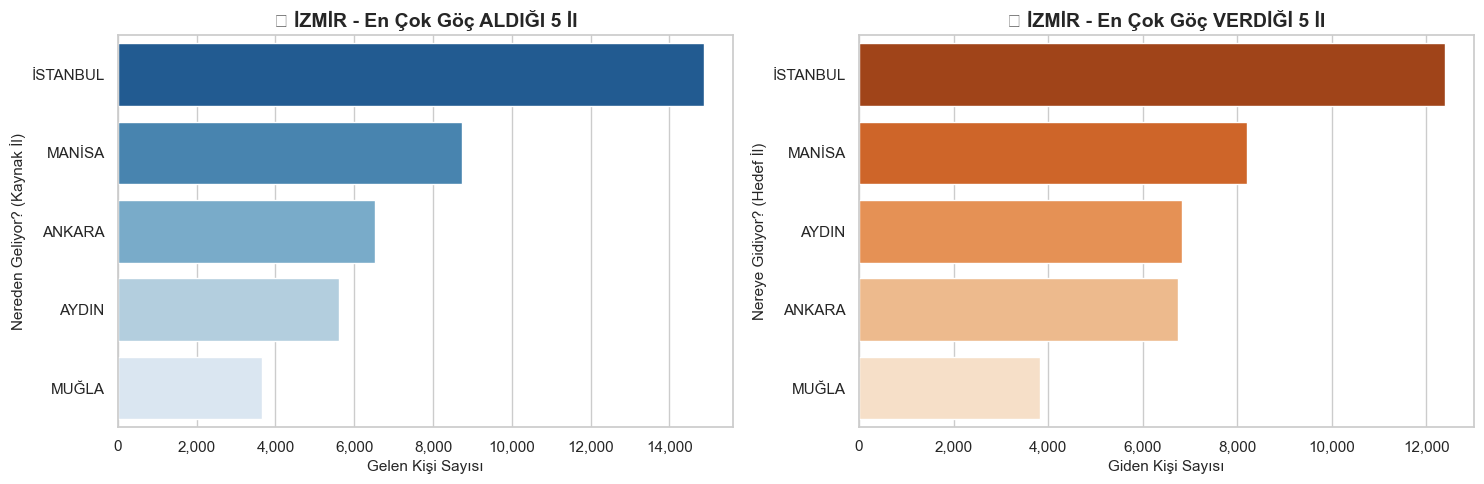

------------------------------------------------------------------------------------------------------------------------


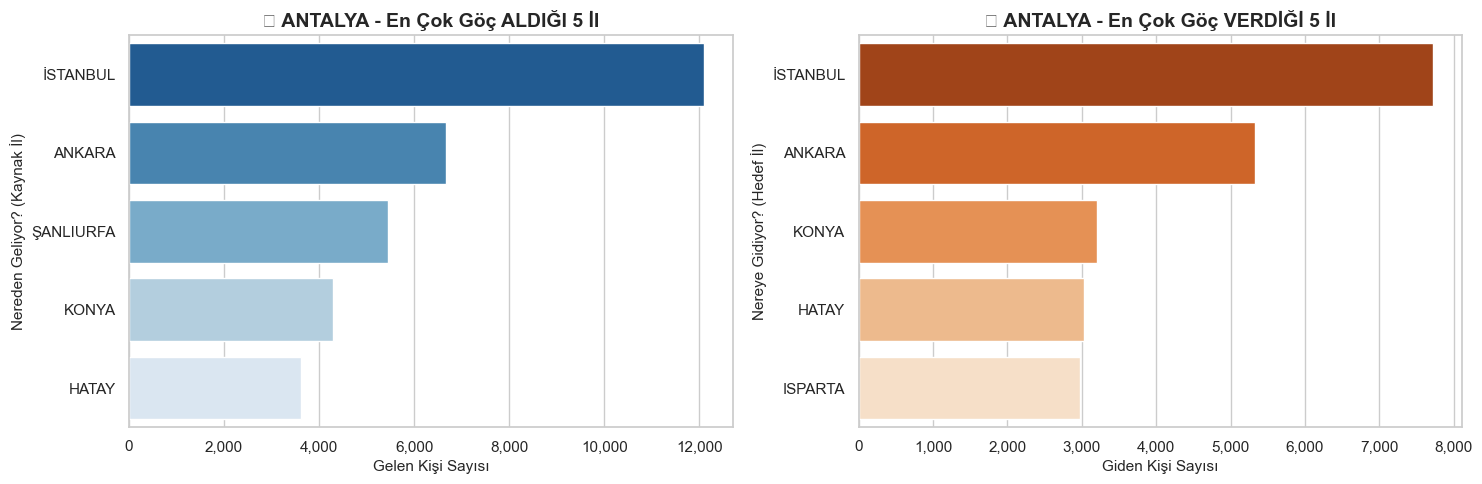

------------------------------------------------------------------------------------------------------------------------


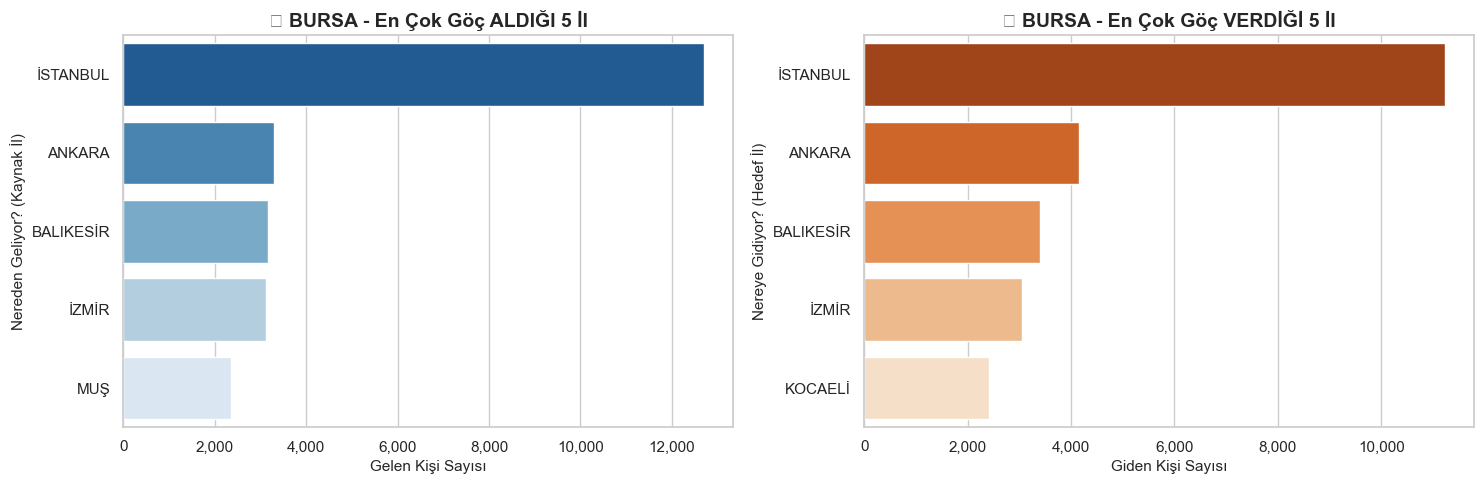

------------------------------------------------------------------------------------------------------------------------


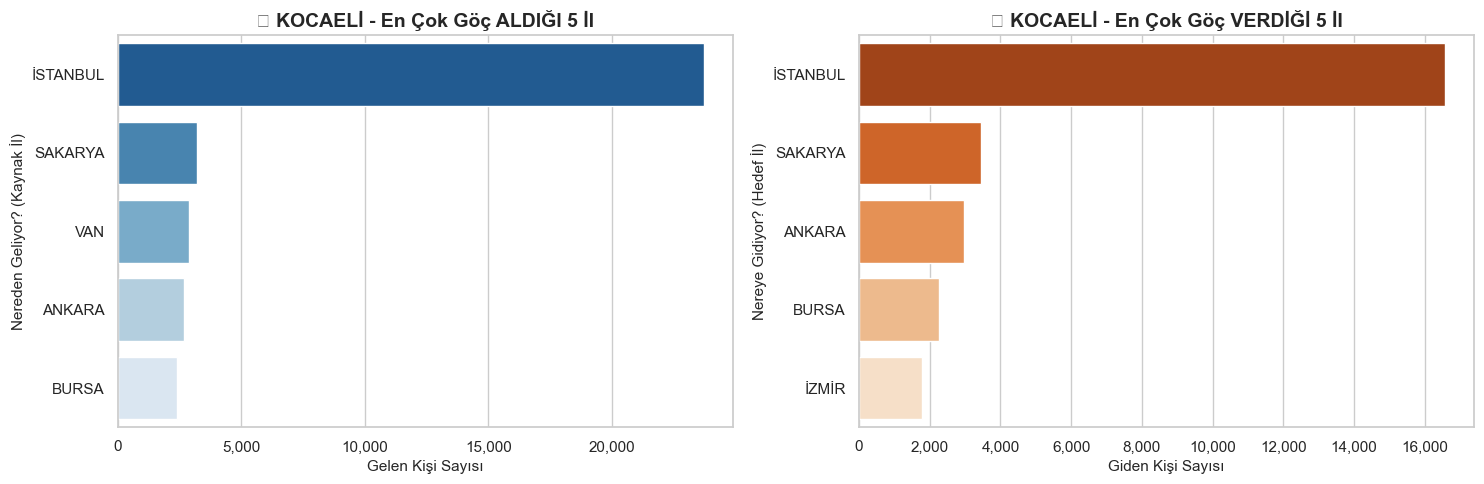

------------------------------------------------------------------------------------------------------------------------


In [27]:
# 8. Zirvedeki Şehirlerin Detaylı Göç Analizi

# Önceki grafikte bulduğumuz İlk 5 Göç Alan ve İlk 5 Göç Veren illeri birleştirip tekil bir liste yapalım
zirvedeki_sehirler = set(top_5_alan['goc_alan_il_adi']).union(set(top_5_veren['goc_veren_il_adi']))

# Şehirleri büyükten küçüğe sıralı (İstanbul, Ankara...) göstermek için
hedef_sehirler = ['İSTANBUL', 'ANKARA', 'İZMİR', 'ANTALYA', 'BURSA', 'KOCAELİ'] 

for sehir in hedef_sehirler:
    # 1. Bu Şehre GELEN Göçler (goc_alan_il_adi == sehir)
    gelen = df_guncel[df_guncel['goc_alan_il_adi'] == sehir].sort_values(by='aldigi_goc', ascending=False).head(5)
    
    # 2. Bu Şehirden GİDEN Göçler (goc_veren_il_adi == sehir)
    giden = df_guncel[df_guncel['goc_veren_il_adi'] == sehir].sort_values(by='aldigi_goc', ascending=False).head(5)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # --- Gelen Göç Grafiği ---
    sns.barplot(data=gelen, x='aldigi_goc', y='goc_veren_il_adi', ax=axes[0], palette='Blues_r')
    axes[0].set_title(f'🎯 {sehir} - En Çok Göç ALDIĞI 5 İl', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Gelen Kişi Sayısı', fontsize=11)
    axes[0].set_ylabel('Nereden Geliyor? (Kaynak İl)', fontsize=11)
    axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    # --- Giden Göç Grafiği ---
    sns.barplot(data=giden, x='aldigi_goc', y='goc_alan_il_adi', ax=axes[1], palette='Oranges_r')
    axes[1].set_title(f'🚀 {sehir} - En Çok Göç VERDİĞİ 5 İl', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Giden Kişi Sayısı', fontsize=11)
    axes[1].set_ylabel('Nereye Gidiyor? (Hedef İl)', fontsize=11)
    axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    plt.tight_layout()
    plt.show()
    print("-" * 120)  # Şehirler arası görsel ayrım için çizgi


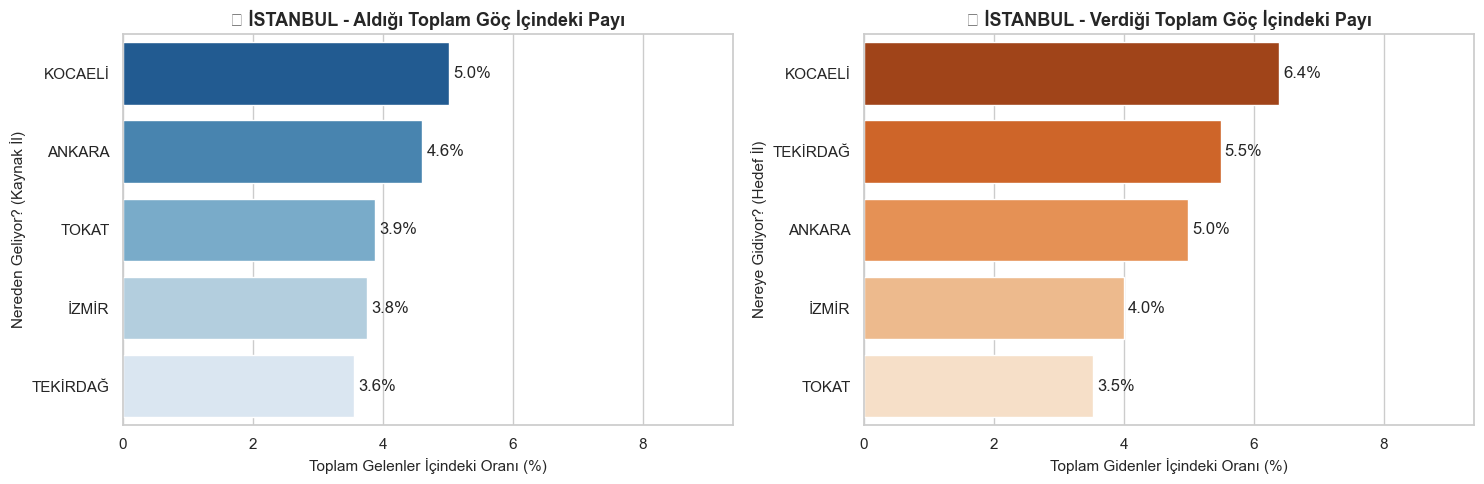

------------------------------------------------------------------------------------------------------------------------


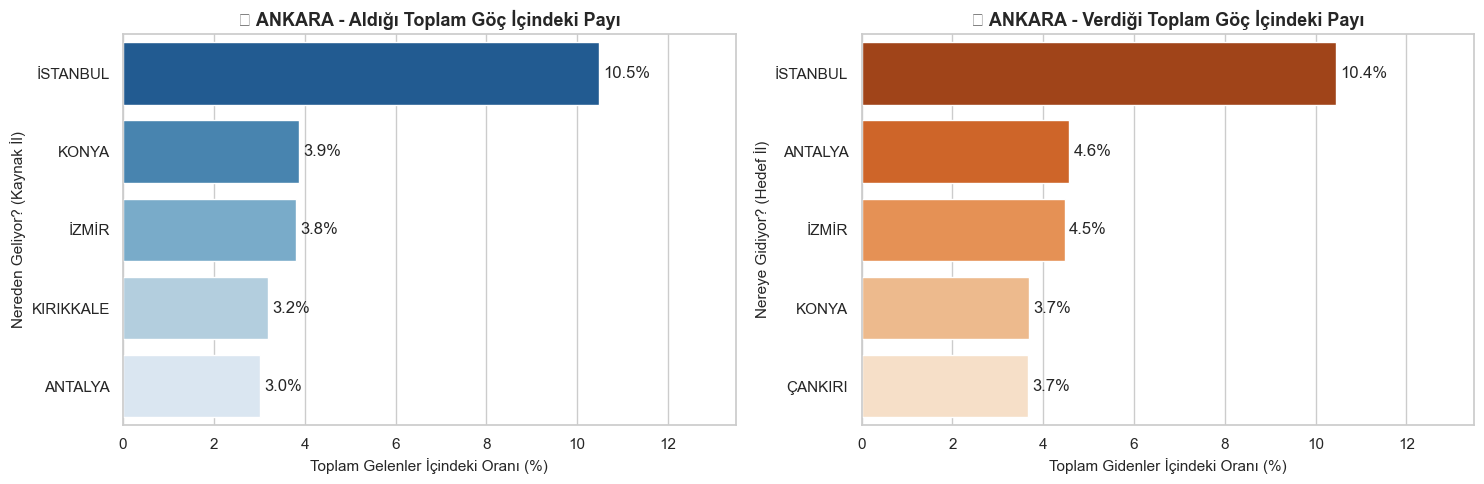

------------------------------------------------------------------------------------------------------------------------


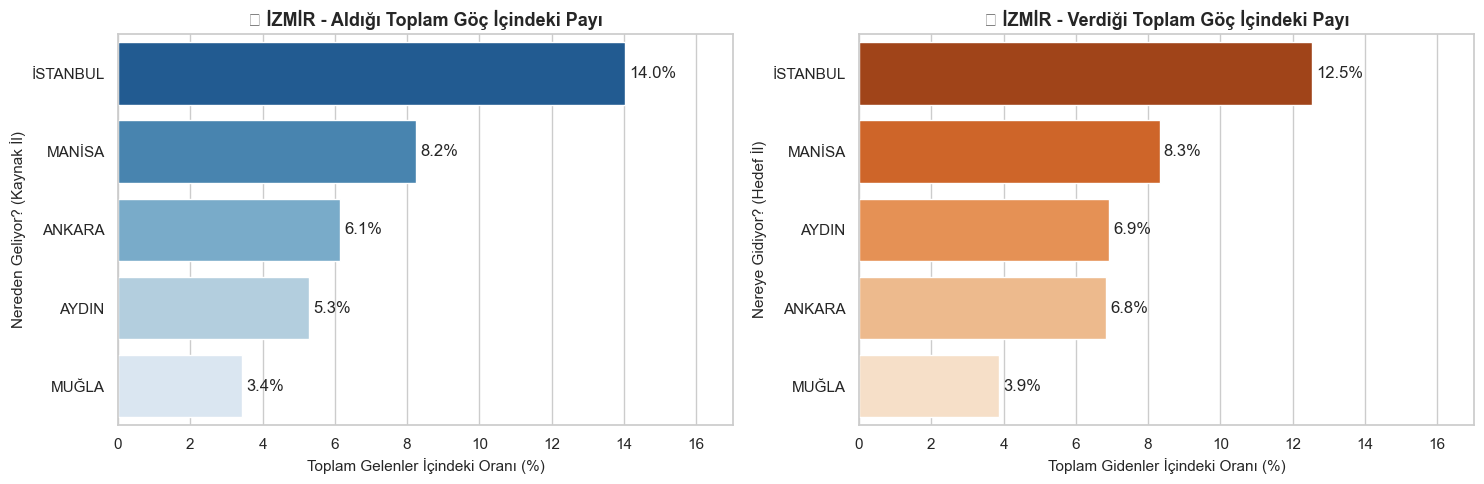

------------------------------------------------------------------------------------------------------------------------


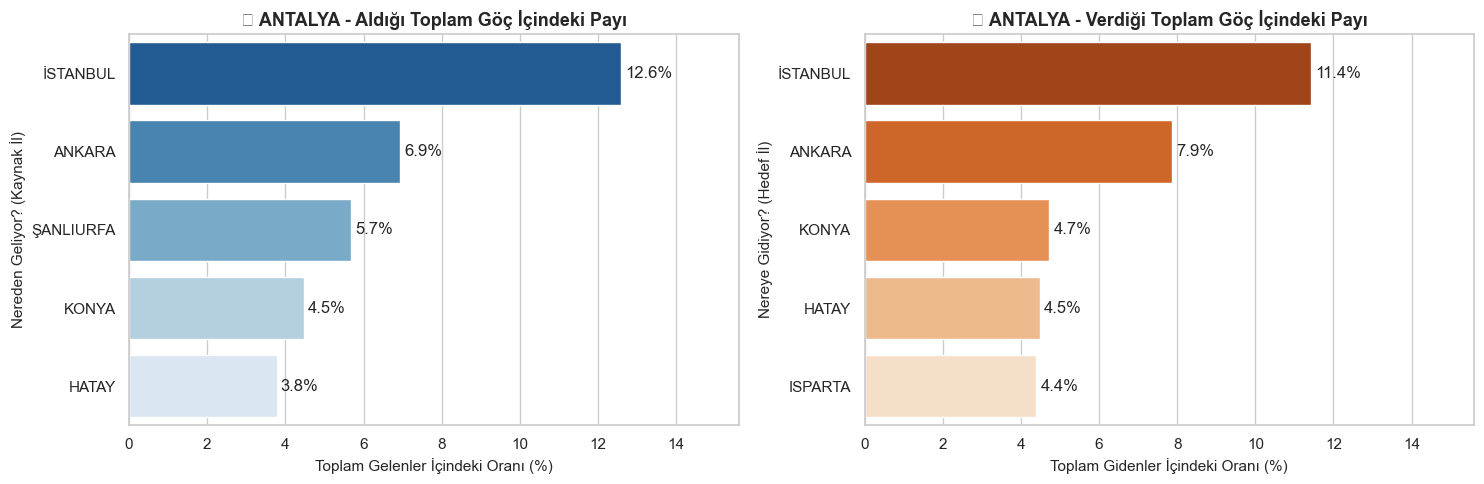

------------------------------------------------------------------------------------------------------------------------


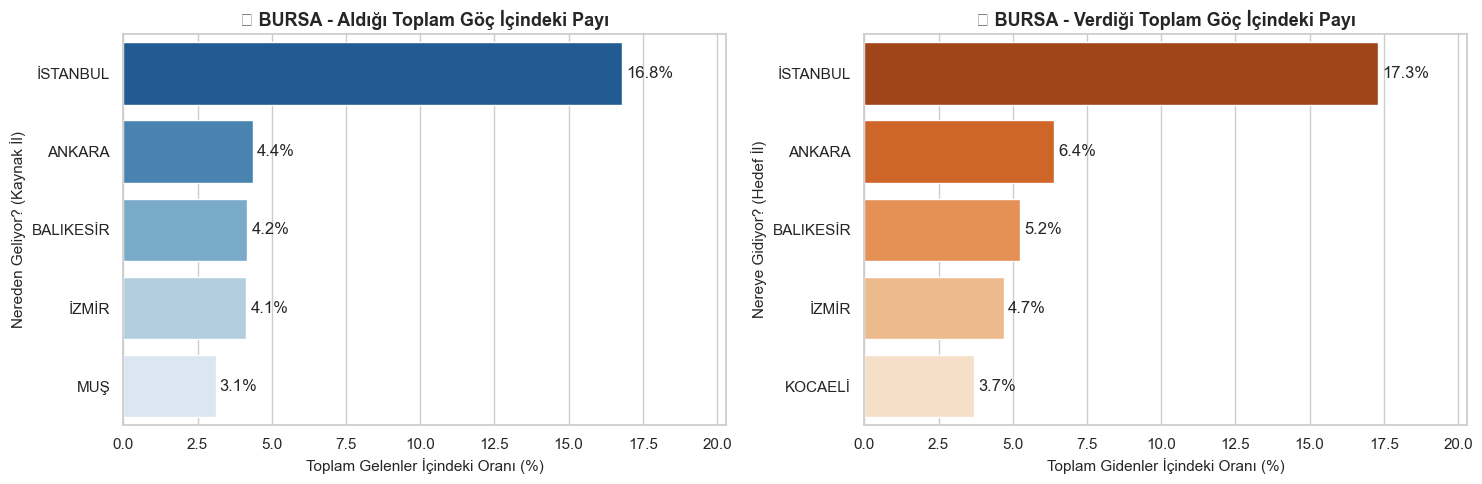

------------------------------------------------------------------------------------------------------------------------


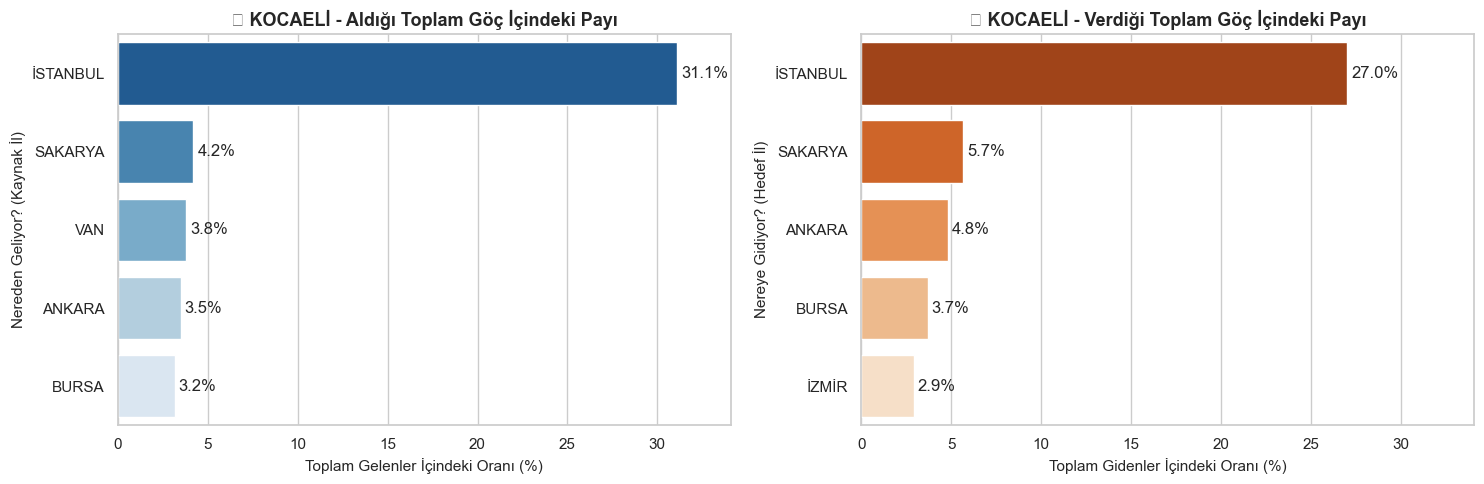

------------------------------------------------------------------------------------------------------------------------


In [28]:
# 9. Zirvedeki Şehirlerin "Yüzdesel" Göç Analizi
hedef_sehirler = ['İSTANBUL', 'ANKARA', 'İZMİR', 'ANTALYA', 'BURSA', 'KOCAELİ'] 

for sehir in hedef_sehirler:
    # 1. Gelen Göç Hesaplaması
    # Şehre Türkiye'nin dört bir yanından gelen TOPLAM göç
    toplam_gelen = df_guncel[df_guncel['goc_alan_il_adi'] == sehir]['aldigi_goc'].sum()
    
    gelen = df_guncel[df_guncel['goc_alan_il_adi'] == sehir].copy()
    gelen['yuzde'] = (gelen['aldigi_goc'] / toplam_gelen) * 100
    gelen = gelen.sort_values(by='yuzde', ascending=False).head(5)
    
    # 2. Giden Göç Hesaplaması
    # Şehirden Türkiye'nin dört bir yanına giden TOPLAM göç
    toplam_giden = df_guncel[df_guncel['goc_veren_il_adi'] == sehir]['aldigi_goc'].sum()
    
    giden = df_guncel[df_guncel['goc_veren_il_adi'] == sehir].copy()
    giden['yuzde'] = (giden['aldigi_goc'] / toplam_giden) * 100
    giden = giden.sort_values(by='yuzde', ascending=False).head(5)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # --- Gelen Göç Grafiği ---
    sns.barplot(data=gelen, x='yuzde', y='goc_veren_il_adi', ax=axes[0], palette='Blues_r')
    axes[0].set_title(f'🎯 {sehir} - Aldığı Toplam Göç İçindeki Payı', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Toplam Gelenler İçindeki Oranı (%)', fontsize=11)
    axes[0].set_ylabel('Nereden Geliyor? (Kaynak İl)', fontsize=11)
    # Maksimum limit belirleme (yazıların dışarı taşmaması için +3 boşluk bırakıyoruz)
    axes[0].set_xlim(0, max(gelen['yuzde'].max(), giden['yuzde'].max()) + 3) 
    
    # Çubukların yanına % değerini yazdırma
    for i in axes[0].containers:
        axes[0].bar_label(i, fmt='%.1f%%', padding=3)
    
    # --- Giden Göç Grafiği ---
    sns.barplot(data=giden, x='yuzde', y='goc_alan_il_adi', ax=axes[1], palette='Oranges_r')
    axes[1].set_title(f'🚀 {sehir} - Verdiği Toplam Göç İçindeki Payı', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Toplam Gidenler İçindeki Oranı (%)', fontsize=11)
    axes[1].set_ylabel('Nereye Gidiyor? (Hedef İl)', fontsize=11)
    axes[1].set_xlim(0, max(gelen['yuzde'].max(), giden['yuzde'].max()) + 3)
    
    for i in axes[1].containers:
        axes[1].bar_label(i, fmt='%.1f%%', padding=3)
    
    plt.tight_layout()
    plt.show()
    print("-" * 120)


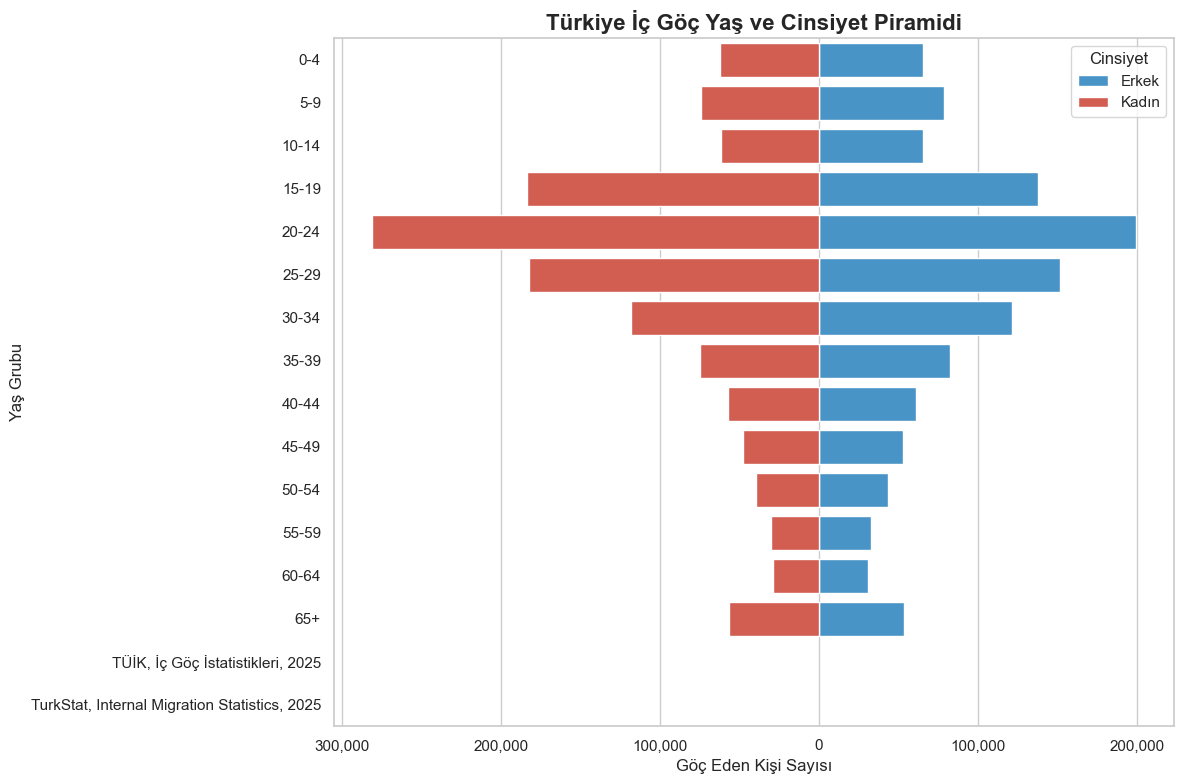

In [29]:
import numpy as np

# 10. Yaş ve Cinsiyete Göre Göç Dağılımı (Nüfus Piramidi)
df_yas = pd.read_csv(PROCESSED_DATA_DIR / 'yas_cinsiyet_goc.csv')

# İlk satır "Toplam" verisi olduğu için çıkarıyoruz, ayrıca "Bilinmeyen" yaş grubunu hariç tutuyoruz
df_yas = df_yas[~df_yas['Yaş grubu Age group'].astype(str).str.contains('Toplam|Bilinmeyen', regex=True)].copy()

# Sütun isimlerini sadeleştirelim
df_yas.rename(columns={'Yaş grubu Age group': 'yas_grubu', 'Erkek Male': 'erkek', 'Kadın Female': 'kadin'}, inplace=True)

# Piramit grafiği oluşturabilmek için kadın verilerini eksi (negatif) eksene yansıtıyoruz
df_yas['kadin_neg'] = df_yas['kadin'] * -1

plt.figure(figsize=(12, 8))
# Erkekler Sağ Tarafa (Pozitif X)
sns.barplot(data=df_yas, x='erkek', y='yas_grubu', color='#3498db', label='Erkek')
# Kadınlar Sol Tarafa (Negatif X)
sns.barplot(data=df_yas, x='kadin_neg', y='yas_grubu', color='#e74c3c', label='Kadın')

plt.title('Türkiye İç Göç Yaş ve Cinsiyet Piramidi', fontsize=16, fontweight='bold')
plt.xlabel('Göç Eden Kişi Sayısı', fontsize=12)
plt.ylabel('Yaş Grubu', fontsize=12)

# X eksenindeki eksi (negatif) işaretlerini kaldırarak görünümü güzelleştirme
ticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([f"{int(abs(tick)):,}" for tick in ticks])

plt.legend(title='Cinsiyet')
plt.tight_layout()
plt.show()

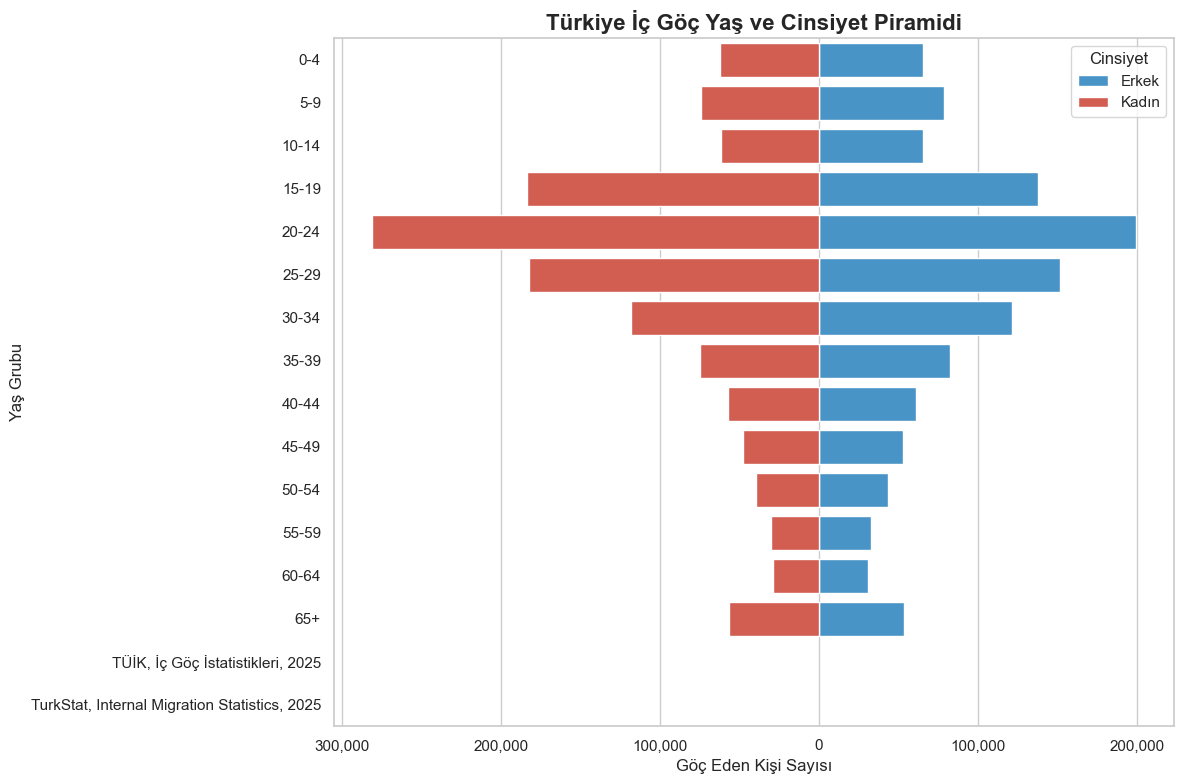

In [30]:
import numpy as np

# 10. Yaş ve Cinsiyete Göre Göç Dağılımı (Nüfus Piramidi)
df_yas = pd.read_csv(PROCESSED_DATA_DIR / 'yas_cinsiyet_goc.csv')

# İlk satır "Toplam" verisi olduğu için çıkarıyoruz, ayrıca "Bilinmeyen" yaş grubunu hariç tutuyoruz
df_yas = df_yas[~df_yas['Yaş grubu Age group'].astype(str).str.contains('Toplam|Bilinmeyen', regex=True)].copy()

# Sütun isimlerini sadeleştirelim
df_yas.rename(columns={'Yaş grubu Age group': 'yas_grubu', 'Erkek Male': 'erkek', 'Kadın Female': 'kadin'}, inplace=True)

# Piramit grafiği oluşturabilmek için kadın verilerini eksi (negatif) eksene yansıtıyoruz
df_yas['kadin_neg'] = df_yas['kadin'] * -1

plt.figure(figsize=(12, 8))
# Erkekler Sağ Tarafa (Pozitif X)
sns.barplot(data=df_yas, x='erkek', y='yas_grubu', color='#3498db', label='Erkek')
# Kadınlar Sol Tarafa (Negatif X)
sns.barplot(data=df_yas, x='kadin_neg', y='yas_grubu', color='#e74c3c', label='Kadın')

plt.title('Türkiye İç Göç Yaş ve Cinsiyet Piramidi', fontsize=16, fontweight='bold')
plt.xlabel('Göç Eden Kişi Sayısı', fontsize=12)
plt.ylabel('Yaş Grubu', fontsize=12)

# X eksenindeki eksi (negatif) işaretlerini kaldırarak görünümü güzelleştirme
ticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([f"{int(abs(tick)):,}" for tick in ticks])

plt.legend(title='Cinsiyet')
plt.tight_layout()
plt.show()

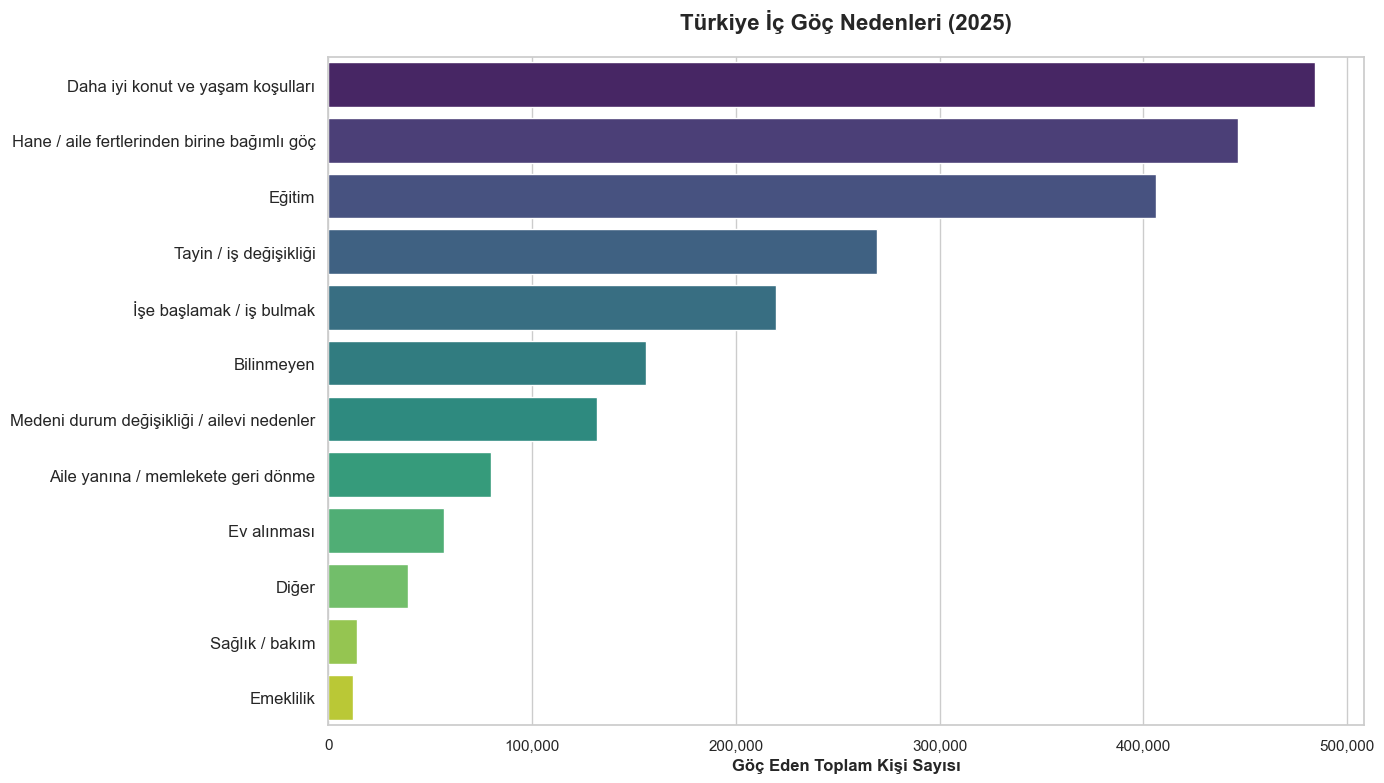

In [31]:
# 11. İnsanlar Neden Göç Ediyor? (Göç Etme Nedenleri)
df_neden = pd.read_csv(PROCESSED_DATA_DIR / 'egitim_goc_nedeni.csv')

# Excel tablosunun altındaki uzun not ve kaynak satırlarını (NaN olanları) silelim
df_neden = df_neden.dropna(subset=['Toplam Total']).copy()

# İlk satırı ("Toplam") çıkaralım
df_neden = df_neden[~df_neden['Göç etme nedeni Reason for migration'].astype(str).str.contains('Toplam', na=False)]

# Sütunda Türkçe - İngilizce isimler yan yana veya alt alta (\n) yazılmış.
# Ayrıca bazılarında dipnot (1) işareti var. Hepsini temizleyip sadece sade Türkçeyi alalım.
def clean_reason(x):
    x = str(x).replace('\n', ' - ') # Alt satıra geçilmiş İngilizceleri tireye çevir
    x = x.split(' - ')[0].strip()    # Tireden sonrasını at
    x = x.replace('(1)', '').strip() # Dipnot numarasını at
    return x

df_neden['Neden'] = df_neden['Göç etme nedeni Reason for migration'].apply(clean_reason)

# En çoktan aza doğru sıralayalım
df_neden_top = df_neden.sort_values(by='Toplam Total', ascending=False)

plt.figure(figsize=(14, 8)) # Grafiği biraz daha büyütelim ki yazılar rahat sığsın
sns.barplot(data=df_neden_top, x='Toplam Total', y='Neden', palette='viridis')

plt.title('Türkiye İç Göç Nedenleri (2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Göç Eden Toplam Kişi Sayısı', fontsize=12, fontweight='bold')
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.yticks(fontsize=12) # Y eksenindeki metinlerin boyutunu biraz büyütelim

plt.tight_layout()
plt.show()


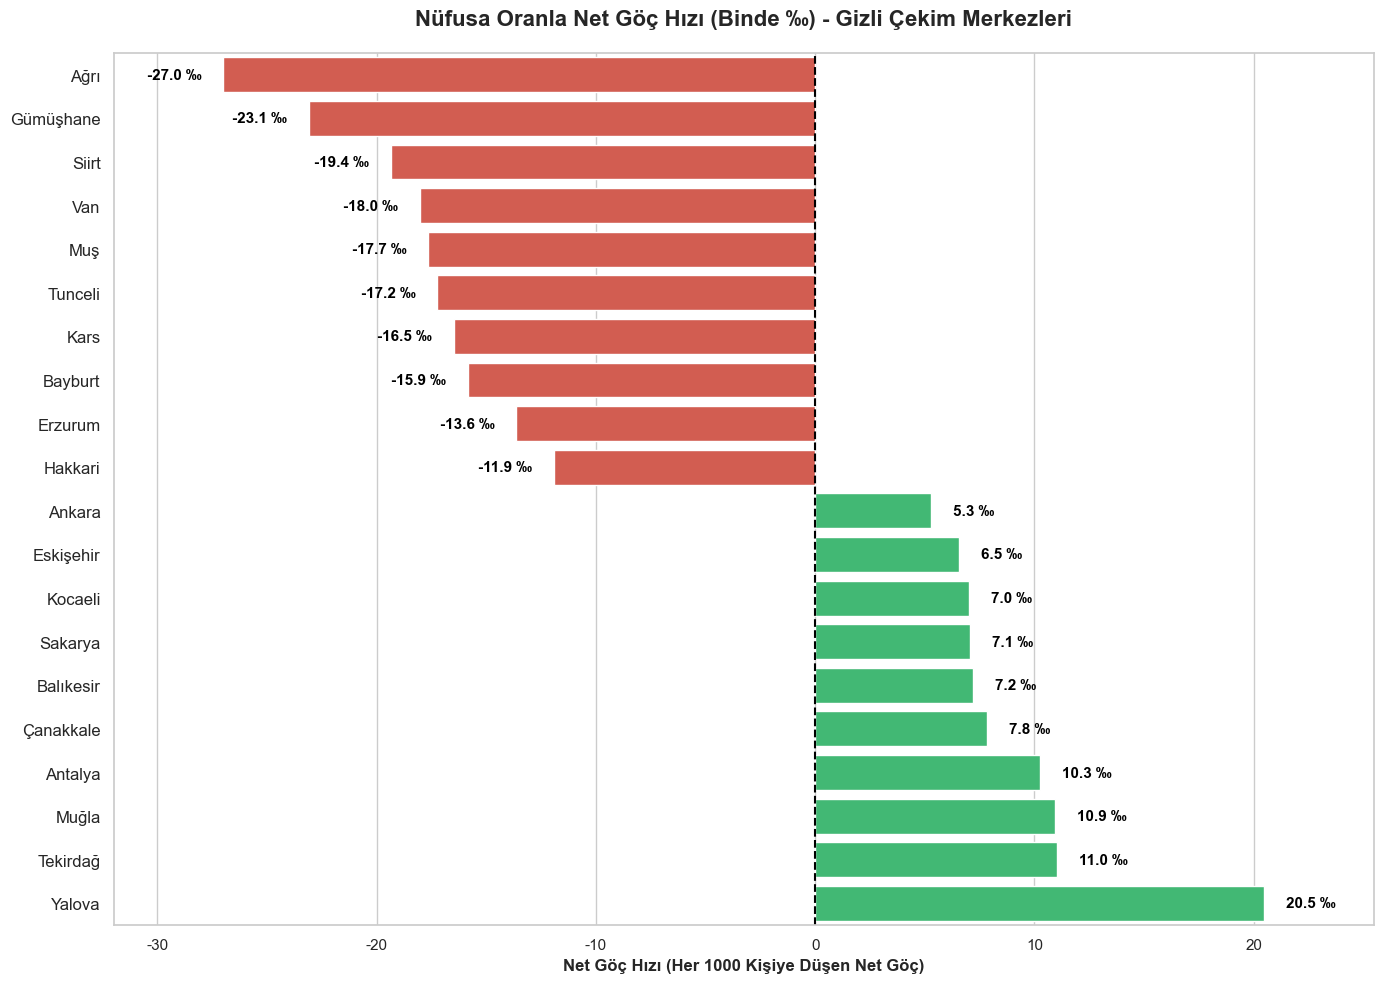

In [32]:
# 12. Nüfusa Oranla Net Göç Hızı (Gizli Çekim Merkezleri ve Kan Kaybedenler)
df_ozet = pd.read_csv(PROCESSED_DATA_DIR / 'illerin_goc_ozeti.csv')

# İlk satırdaki "Toplam" verisini çıkaralım
df_ozet = df_ozet[~df_ozet['İl Province'].str.contains('Toplam', na=False)].copy()

# Kolay kullanım için sütun isimlerini sadeleştirelim
df_ozet = df_ozet.rename(columns={
    'İl Province': 'İl',
    'Net göç hızı Rate of net migration (‰)': 'Net_Goc_Hizi_Binde'
})

# En yüksek net göç hızına sahip 10 il (Nüfusuna oranla en hızlı büyüyenler)
en_yuksek_hiz = df_ozet.nlargest(10, 'Net_Goc_Hizi_Binde')

# En düşük net göç hızına sahip 10 il (Nüfusuna oranla en hızlı eriyenler)
en_dusuk_hiz = df_ozet.nsmallest(10, 'Net_Goc_Hizi_Binde')

# Grafik için iki grubu birleştirelim
df_hiz_karsilastirma = pd.concat([en_yuksek_hiz, en_dusuk_hiz]).sort_values('Net_Goc_Hizi_Binde', ascending=True)

# Renkleri belirleyelim: Kazananlar Yeşil, Kaybedenler Kırmızı
renkler = ['#e74c3c' if val < 0 else '#2ecc71' for val in df_hiz_karsilastirma['Net_Goc_Hizi_Binde']]

plt.figure(figsize=(14, 10))
grafik = sns.barplot(
    data=df_hiz_karsilastirma, 
    x='Net_Goc_Hizi_Binde', 
    y='İl', 
    palette=renkler,
    hue='İl',       # Seaborn yeni sürümlerindeki uyarıları önlemek için
    legend=False    # Lejanda gerek yok
)

# Ortaya net bir 0 (Sıfır) ekseni çizelim
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

plt.title('Nüfusa Oranla Net Göç Hızı (Binde ‰) - Gizli Çekim Merkezleri', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Net Göç Hızı (Her 1000 Kişiye Düşen Net Göç)', fontsize=12, fontweight='bold')
plt.ylabel('', fontsize=12)
plt.yticks(fontsize=12)

# Barların uç kısımlarına değerleri (‰) yazdıralım
for i, v in enumerate(df_hiz_karsilastirma['Net_Goc_Hizi_Binde']):
    # Artıysa sağa, eksiyse sola doğru yazdır
    offset = 1.0 if v > 0 else -1.0
    hizalama = 'left' if v > 0 else 'right'
    
    grafik.text(
        v + offset, i, 
        f'{v:.1f} ‰', 
        color='black', va='center', ha=hizalama, fontsize=11, fontweight='bold'
    )

# Grafiğin sınırlarını yazılar taşmayacak şekilde biraz genişletelim
plt.xlim(df_hiz_karsilastirma['Net_Goc_Hizi_Binde'].min() - 5, df_hiz_karsilastirma['Net_Goc_Hizi_Binde'].max() + 5)

plt.tight_layout()
plt.show()


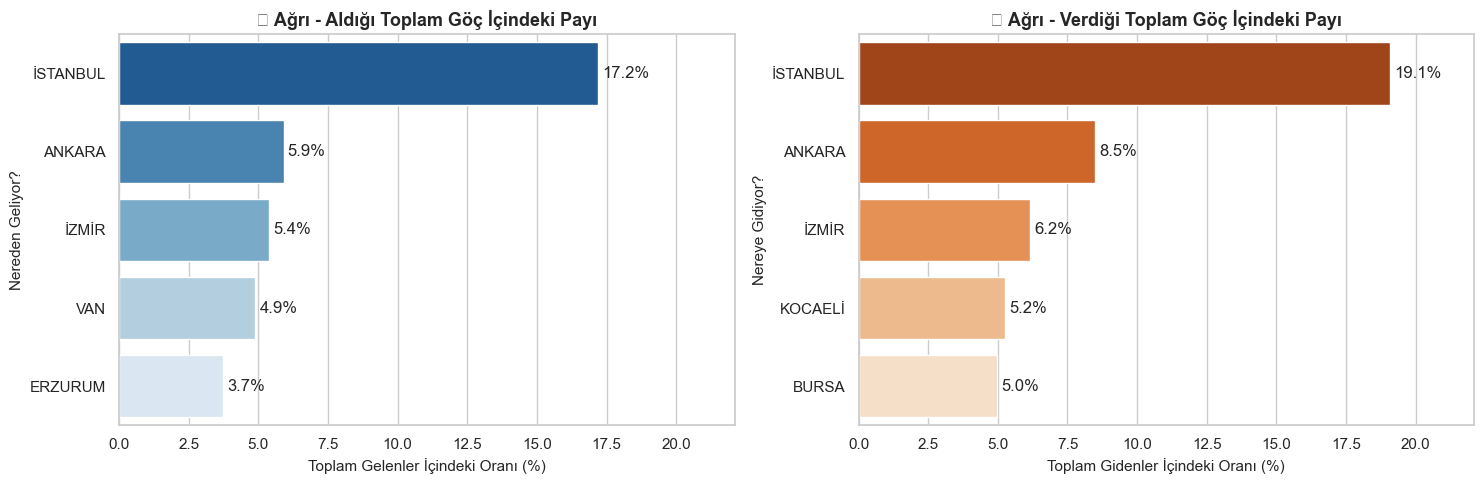

------------------------------------------------------------------------------------------------------------------------


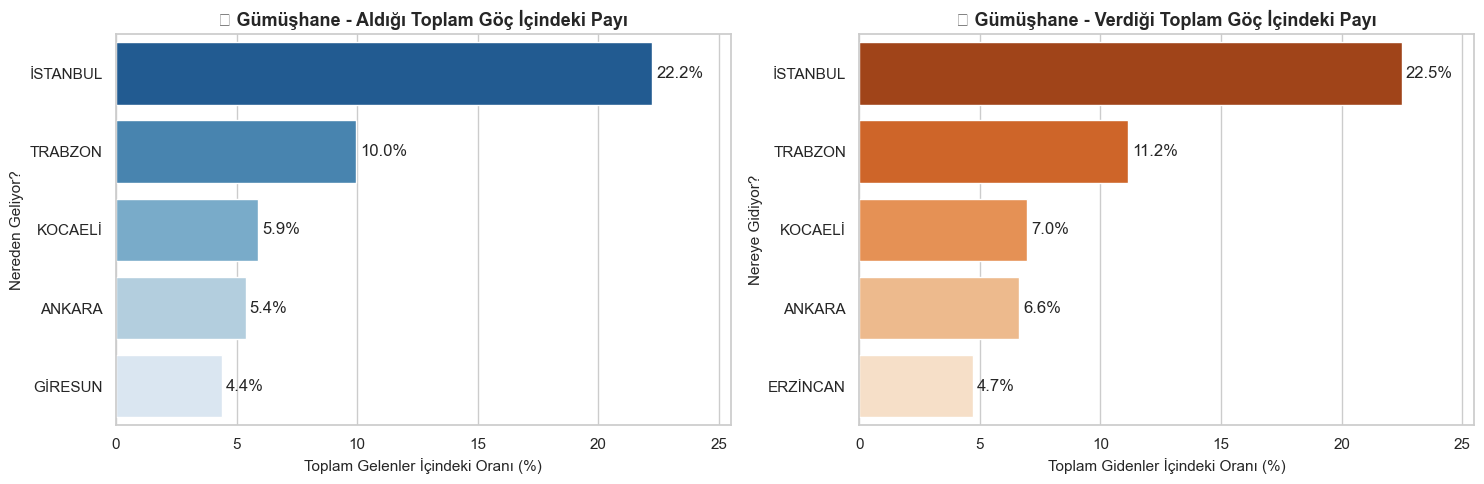

------------------------------------------------------------------------------------------------------------------------


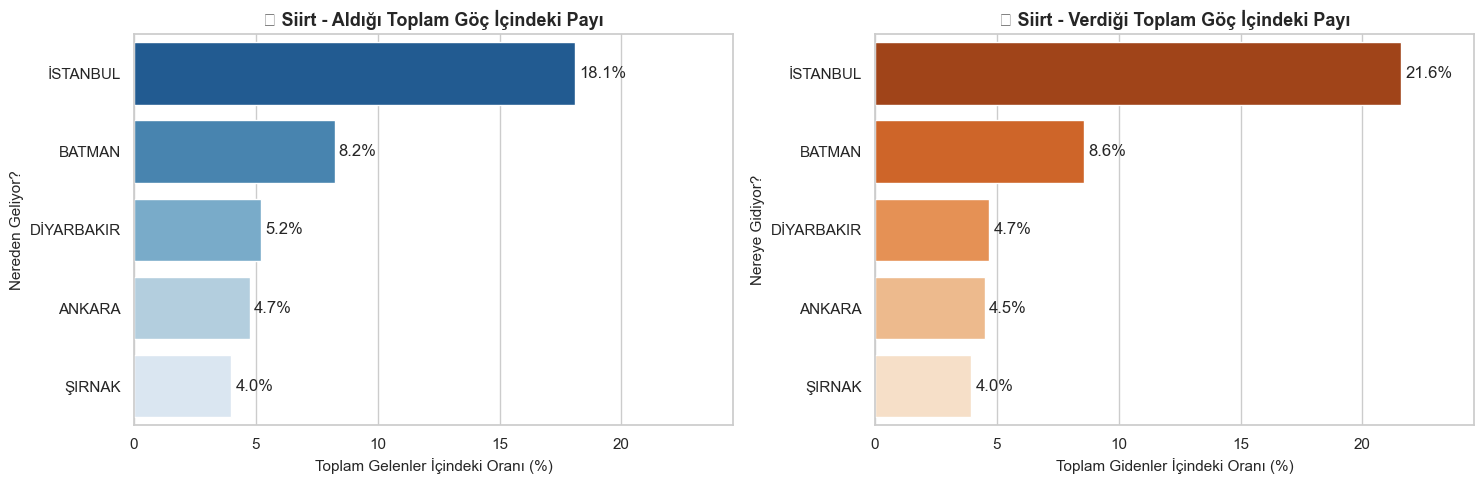

------------------------------------------------------------------------------------------------------------------------


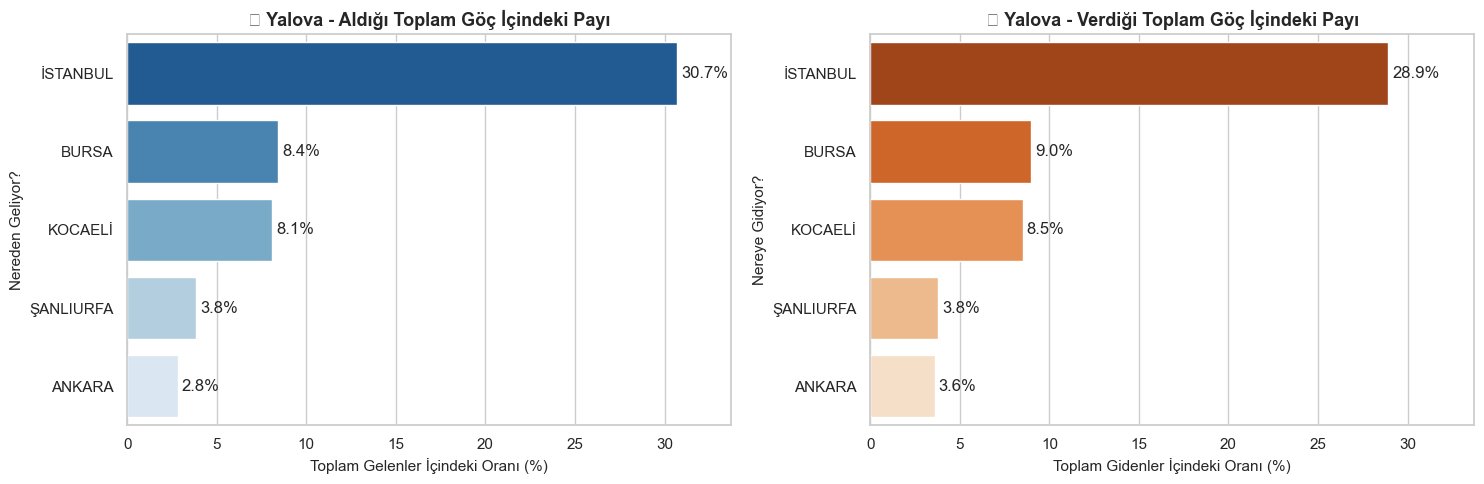

------------------------------------------------------------------------------------------------------------------------


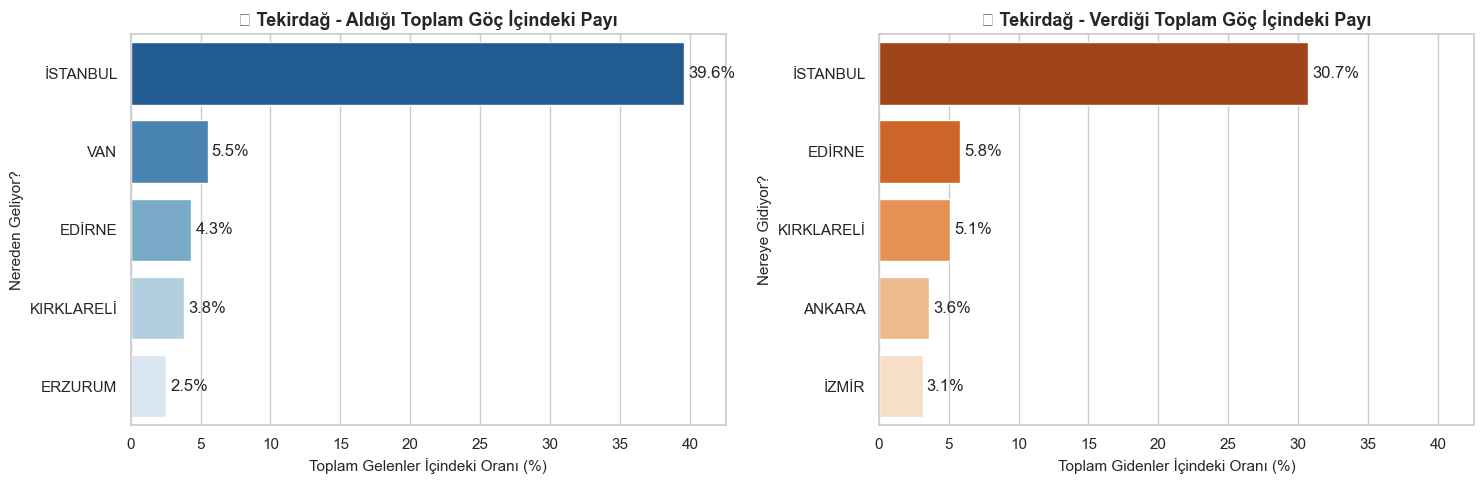

------------------------------------------------------------------------------------------------------------------------


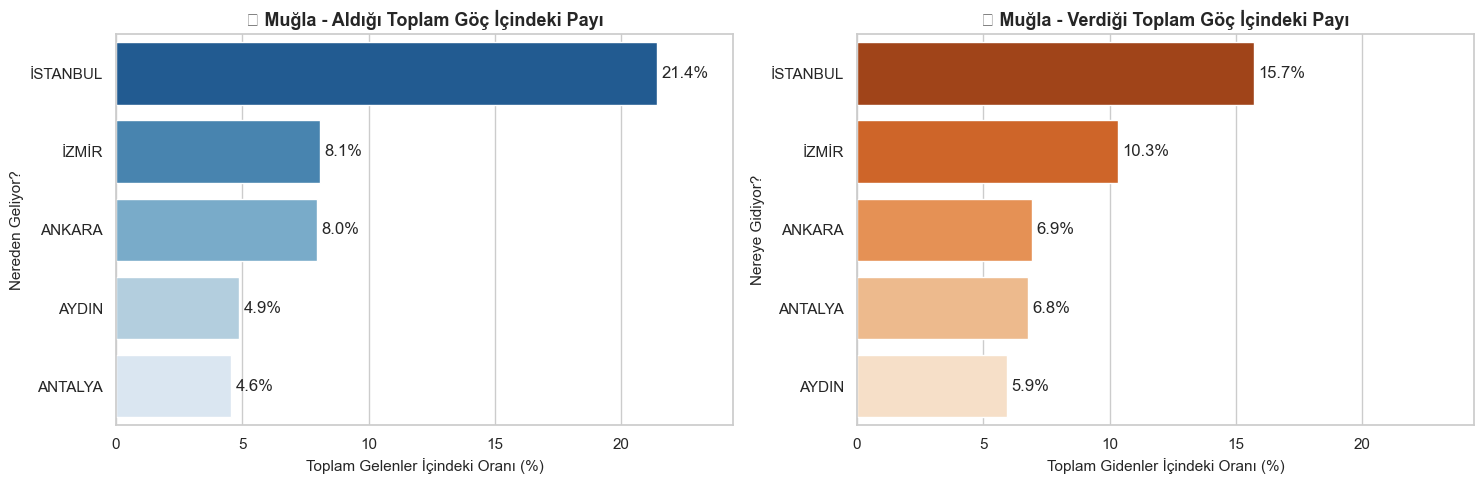

------------------------------------------------------------------------------------------------------------------------


In [33]:
# 13. En Çok Kan Kaybedenler ve Gizli Çekim Merkezlerinin "Yüzdesel Göç" Analizi

# Grafikteki en uç 3 Kaybeden ve en uç 3 Kazananı listelerimize alalım
kaybeden_3 = en_dusuk_hiz.head(3)['İl'].tolist()   # Ağrı, Gümüşhane, Siirt
kazanan_3 = en_yuksek_hiz.head(3)['İl'].tolist()   # Yalova, Tekirdağ, Muğla

secili_sehirler_ham = kaybeden_3 + kazanan_3

# Veri setindeki (df_guncel) formatına uydurmak için Türkçe kurallarına göre BÜYÜK HARFE çevirelim
def tr_upper(text):
    return text.replace('i', 'İ').replace('ı', 'I').upper()

secili_sehirler = [tr_upper(il) for il in secili_sehirler_ham]

for sehir, orjinal_isim in zip(secili_sehirler, secili_sehirler_ham):
    # 1. Gelen Göç Hesaplaması
    toplam_gelen = df_guncel[df_guncel['goc_alan_il_adi'] == sehir]['aldigi_goc'].sum()
    gelen = df_guncel[df_guncel['goc_alan_il_adi'] == sehir].copy()
    
    if toplam_gelen > 0:
        gelen['yuzde'] = (gelen['aldigi_goc'] / toplam_gelen) * 100
        gelen = gelen.sort_values(by='yuzde', ascending=False).head(5)
    
    # 2. Giden Göç Hesaplaması
    toplam_giden = df_guncel[df_guncel['goc_veren_il_adi'] == sehir]['aldigi_goc'].sum()
    giden = df_guncel[df_guncel['goc_veren_il_adi'] == sehir].copy()
    
    if toplam_giden > 0:
        giden['yuzde'] = (giden['aldigi_goc'] / toplam_giden) * 100
        giden = giden.sort_values(by='yuzde', ascending=False).head(5)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    max_x = 0
    
    # --- Gelen Göç Grafiği ---
    if not gelen.empty:
        sns.barplot(data=gelen, x='yuzde', y='goc_veren_il_adi', ax=axes[0], palette='Blues_r')
        for i in axes[0].containers: axes[0].bar_label(i, fmt='%.1f%%', padding=3)
        max_x = gelen['yuzde'].max()
        
    axes[0].set_title(f'🎯 {orjinal_isim} - Aldığı Toplam Göç İçindeki Payı', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Toplam Gelenler İçindeki Oranı (%)', fontsize=11)
    axes[0].set_ylabel('Nereden Geliyor?', fontsize=11)
    
    # --- Giden Göç Grafiği ---
    if not giden.empty:
        sns.barplot(data=giden, x='yuzde', y='goc_alan_il_adi', ax=axes[1], palette='Oranges_r')
        for i in axes[1].containers: axes[1].bar_label(i, fmt='%.1f%%', padding=3)
        max_x = max(max_x, giden['yuzde'].max())
    
    axes[1].set_title(f'🚀 {orjinal_isim} - Verdiği Toplam Göç İçindeki Payı', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Toplam Gidenler İçindeki Oranı (%)', fontsize=11)
    axes[1].set_ylabel('Nereye Gidiyor?', fontsize=11)
    
    axes[0].set_xlim(0, max_x + 3)
    axes[1].set_xlim(0, max_x + 3)
    
    plt.tight_layout()
    plt.show()
    print("-" * 120)


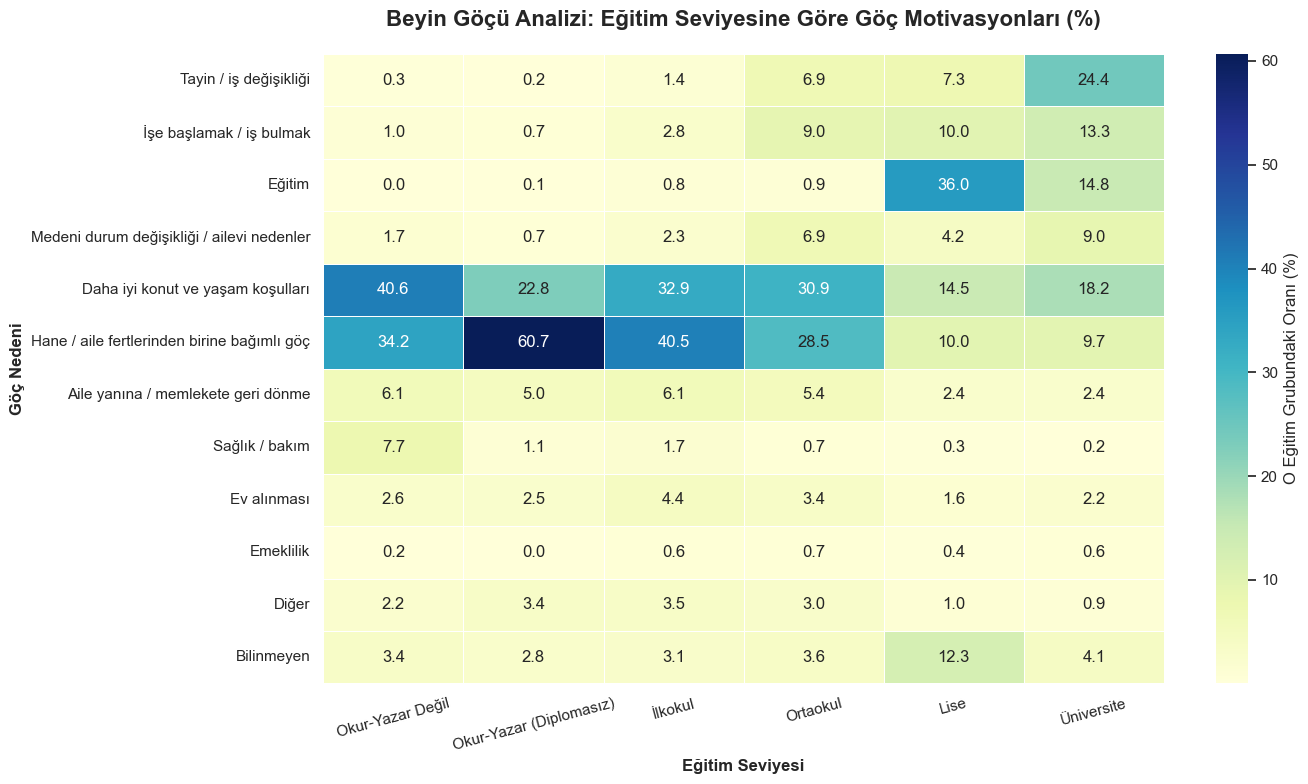

In [34]:
# 14. Beyin Göçü Analizi (Eğitim Seviyesi ve Göç Motivasyonu)
df_egitim = pd.read_csv(PROCESSED_DATA_DIR / 'egitim_goc_nedeni.csv')

# Excel altındaki uzun notları (NaN olanları) silelim
df_egitim = df_egitim.dropna(subset=['Toplam Total']).copy()

# 'Toplam' satırını çıkaralım
df_egitim = df_egitim[~df_egitim['Göç etme nedeni Reason for migration'].astype(str).str.contains('Toplam', na=False)]

# Nedenleri temizleyip sade Türkçe hale getirelim (Önceki fonksiyonumuz)
def clean_reason(x):
    x = str(x).replace('\n', ' - ').split(' - ')[0].strip()
    return x.replace('(1)', '').strip()

df_egitim['Neden'] = df_egitim['Göç etme nedeni Reason for migration'].apply(clean_reason)
df_egitim.set_index('Neden', inplace=True) # Y ekseni (Satırlar) Göç Nedenleri olacak

# İlgilendiğimiz Eğitim Sütunları ve onlara vereceğimiz Kısa Türkçe İsimler
egitim_kolonlari = {
    'Okuma yazma bilmeyen  Illiterate': 'Okur-Yazar Değil',
    'Okuma yazma bilen fakat  bir okul bitirmeyen Literate  without  a diploma': 'Okur-Yazar (Diplomasız)',
    'İlkokul Primary school': 'İlkokul',
    'İlköğretim,  ortaokul veya  dengi okul Primary education  lower secondary  school': 'Ortaokul',
    'Lise veya dengi okul Upper secondary school': 'Lise',
    'Yükseköğretim Higher  education': 'Üniversite'
}

# Sadece eğitim kolonlarını seçip isimlerini Türkçe kısaltmalarla değiştirelim
df_heatmap = df_egitim[list(egitim_kolonlari.keys())].rename(columns=egitim_kolonlari)

# Verileri güvenli şekilde sayısal (float) formata çevirelim
for col in df_heatmap.columns:
    df_heatmap[col] = pd.to_numeric(df_heatmap[col], errors='coerce')

# --- CAN ALICI NOKTA: Sütun Bazlı Yüzdelik Oran ---
# Soru: "O eğitim grubundaki insanların toplamda yüzde kaçı hangi sebeple göç etti?"
# Her hücreyi, bulunduğu SÜTUNUN TOPLAMINA bölüp 100 ile çarpıyoruz.
df_yuzde = df_heatmap.div(df_heatmap.sum(axis=0), axis=1) * 100

plt.figure(figsize=(14, 8))
# cmap='YlGnBu' -> Sarıdan Koyu Maviye renk skalası
sns.heatmap(df_yuzde, annot=True, fmt=".1f", cmap='YlGnBu', linewidths=0.5, 
            cbar_kws={'label': 'O Eğitim Grubundaki Oranı (%)'})

plt.title('Beyin Göçü Analizi: Eğitim Seviyesine Göre Göç Motivasyonları (%)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Eğitim Seviyesi', fontsize=12, fontweight='bold')
plt.ylabel('Göç Nedeni', fontsize=12, fontweight='bold')

plt.xticks(rotation=15, fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()


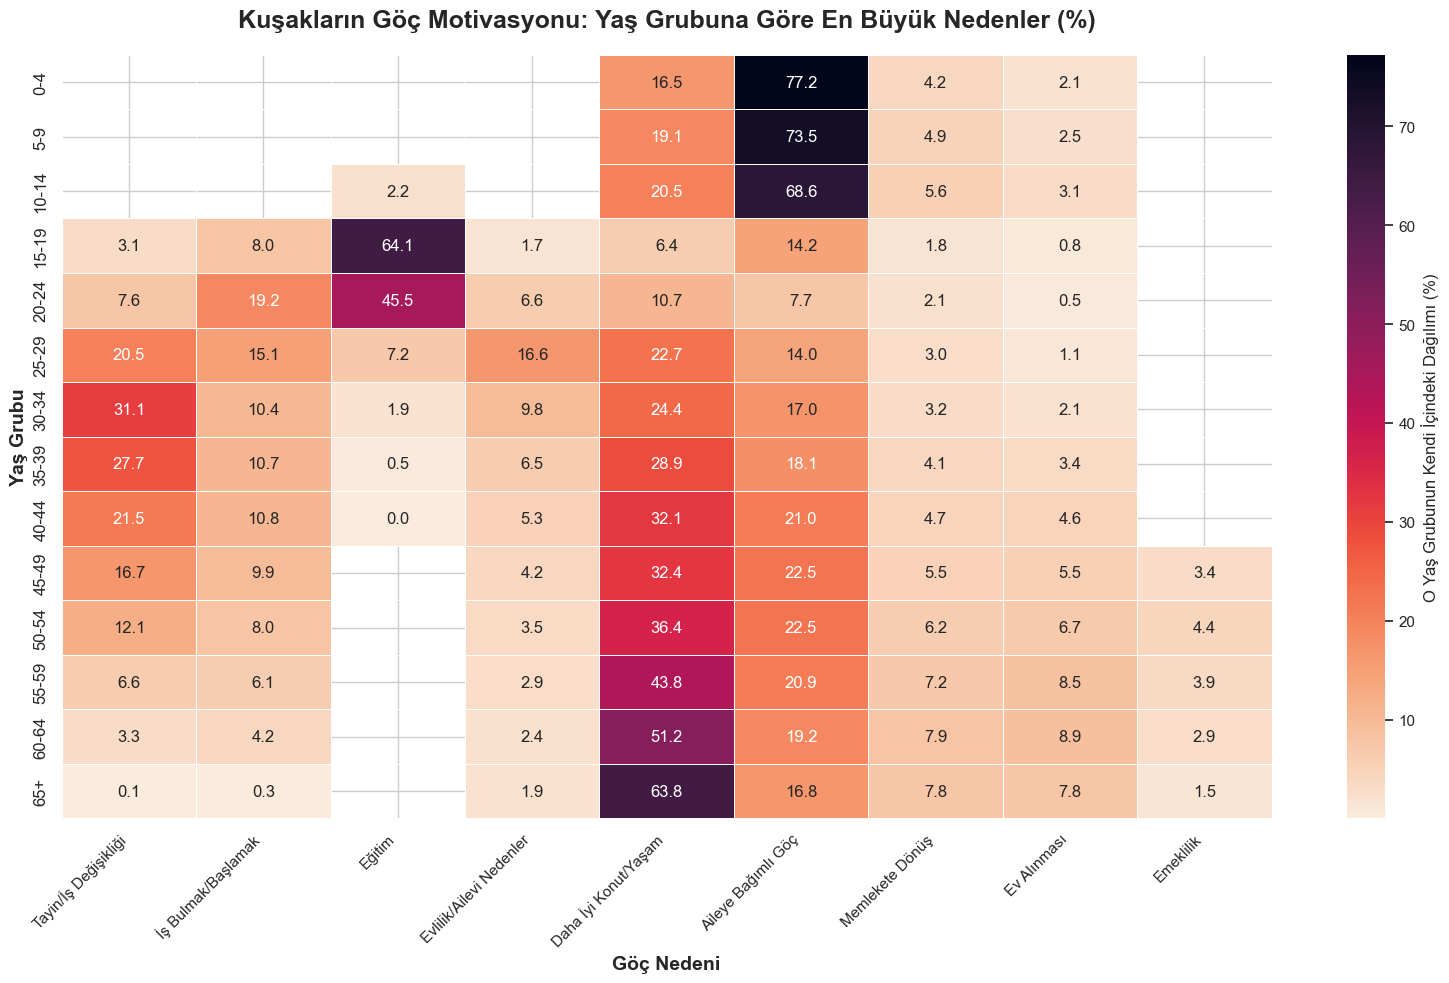

In [35]:
# 15. Kuşakların Göç Motivasyonu (Yaş Grubu vs. Göç Nedeni)
df_yas_neden = pd.read_csv(PROCESSED_DATA_DIR / 'yas_cinsiyet_neden.csv')

# Excel yapısı gereği yaş grupları sadece ilk satırda yazar, altındaki Kadın/Erkek satırlarında boş(NaN) olur
# Bu boşlukları üstündeki yaş grubuyla dolduralım (Forward Fill)
df_yas_neden['Yaş grubu Age group'] = df_yas_neden['Yaş grubu Age group'].ffill()

# Kadın/Erkek ayrımına girmeden sadece o yaş grubunun "Toplam" satırlarını alalım
df_yas_neden = df_yas_neden[df_yas_neden['Cinsiyet Sex'] == 'Toplam-Total']

# "Toplam", "Bilinmeyen" yaş gruplarını ve alakasız veri satırlarını filtreleyelim
df_yas_neden = df_yas_neden.dropna(subset=['Toplam Total']).copy()
df_yas_neden = df_yas_neden[~df_yas_neden['Yaş grubu Age group'].astype(str).str.contains('Toplam|Bilinmeyen|\(', regex=True)]

# İndeksimizi Yaş Grubu yapalım
df_yas_neden.set_index('Yaş grubu Age group', inplace=True)

# Uzun İngilizce-Türkçe karışık sütun isimlerini temiz, kısa Türkçe isimlerle eşleştirelim
neden_kolonlari = {
    'Tayin / iş değişikliği Assignation / change of job': 'Tayin/İş Değişikliği',
    'İşe  başlamak / iş bulmak Starting / finding a job': 'İş Bulmak/Başlamak',
    'Eğitim Education': 'Eğitim',
    'Medeni durum değişikliği / ailevi nedenler  Change of marital status / family-related reasons': 'Evlilik/Ailevi Nedenler',
    'Daha iyi konut  ve yaşam koşulları  Better  housing and  living conditions': 'Daha İyi Konut/Yaşam',
    'Hane / aile fertlerinden  birine bağımlı göç Migration related to any member of the household / family': 'Aileye Bağımlı Göç',
    'Aile yanına / memlekete geri dönme(1)  Returning to family home / hometown(1)': 'Memlekete Dönüş',
    'Ev alınması Buying a house': 'Ev Alınması',
    'Emeklilik Retirement': 'Emeklilik'
}

# Sadece ilgili sütunları alıp isimlerini değiştirelim
df_heatmap_yas = df_yas_neden[list(neden_kolonlari.keys())].rename(columns=neden_kolonlari)

# Verileri tamamen sayısal (float) yapalım
for col in df_heatmap_yas.columns:
    df_heatmap_yas[col] = pd.to_numeric(df_heatmap_yas[col], errors='coerce')

# --- CAN ALICI NOKTA: Satır Bazlı Yüzdelik Oran ---
# Soru: "Bu yaş grubundaki (Örn 20-24) insanların yüzde kaçı hangi sebeple göç etti?"
# Her hücreyi, bulunduğu SATIRIN TOPLAMINA bölüp 100 ile çarpıyoruz.
df_yuzde_yas = df_heatmap_yas.div(df_heatmap_yas.sum(axis=1), axis=0) * 100

plt.figure(figsize=(16, 10))
# Kırmızıdan mora sıcak bir renk teması (Reds veya rocket çok şık durur)
sns.heatmap(df_yuzde_yas, annot=True, fmt=".1f", cmap='rocket_r', linewidths=0.5, 
            cbar_kws={'label': 'O Yaş Grubunun Kendi İçindeki Dağılımı (%)'})

plt.title('Kuşakların Göç Motivasyonu: Yaş Grubuna Göre En Büyük Nedenler (%)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Göç Nedeni', fontsize=14, fontweight='bold')
plt.ylabel('Yaş Grubu', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


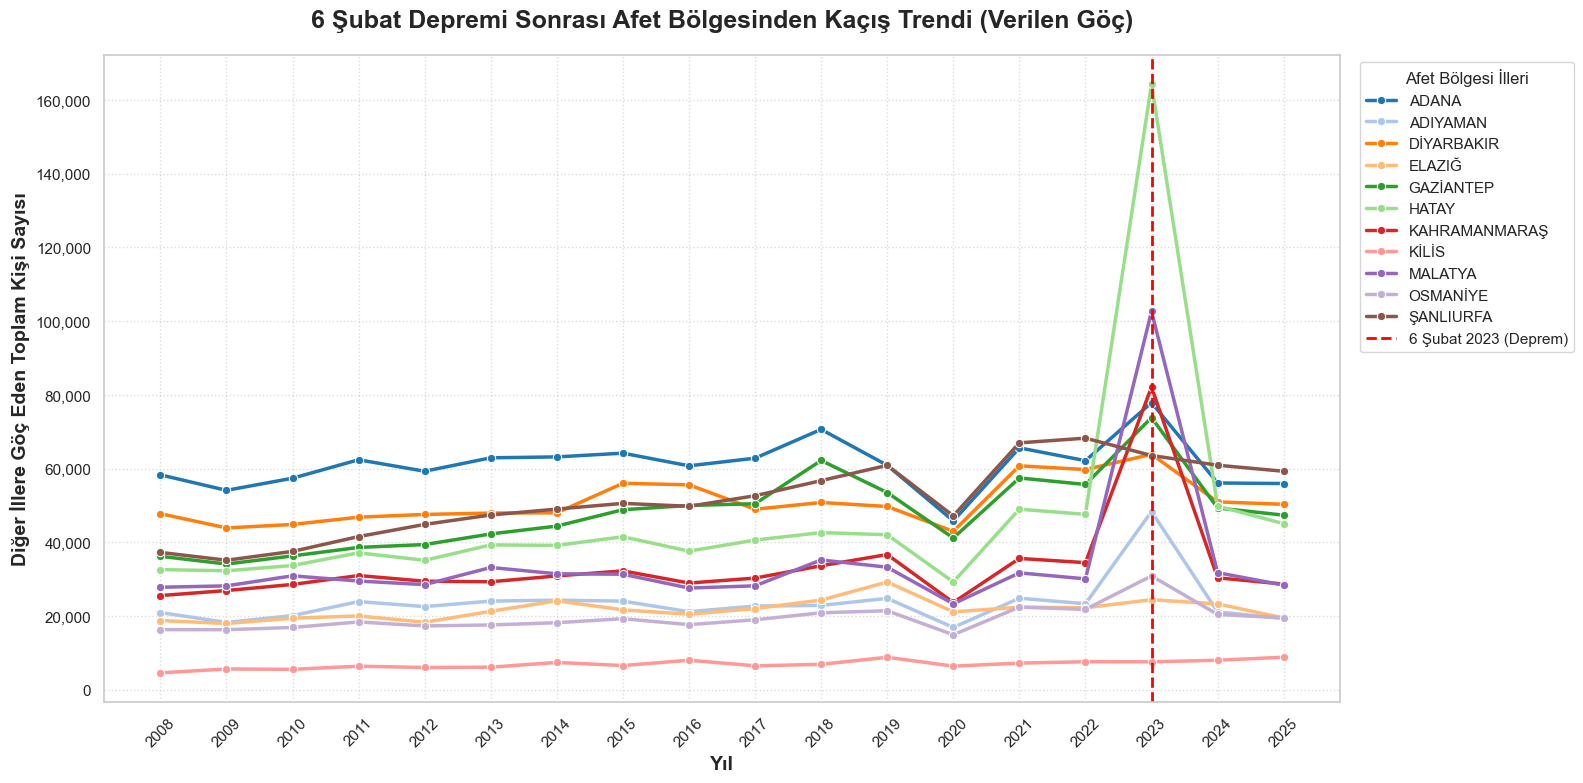

In [36]:
# 16. Kriz Analizi: 6 Şubat Depreminin Göç Dalgalarına Etkisi
# Depremden en çok etkilenen 11 ilin yıllara göre diğer illere "Verdiği Göçü" inceleyelim.

deprem_illeri = ['HATAY', 'KAHRAMANMARAŞ', 'ADIYAMAN', 'MALATYA', 'GAZİANTEP', 
                 'ŞANLIURFA', 'DİYARBAKIR', 'ADANA', 'OSMANİYE', 'KİLİS', 'ELAZIĞ']

# Sadece bu illerin "Göç Veren (Kaynak)" olduğu satırları, TÜM YILLARI kapsayan ana df'den çekelim
df_deprem = df[df['goc_veren_il_adi'].isin(deprem_illeri)].copy()

# Yıllara ve İllere göre gruplayıp, o yıl dışarıya giden toplam insan sayısını bulalım
deprem_goc_trendi = df_deprem.groupby(['yil', 'goc_veren_il_adi'])['aldigi_goc'].sum().reset_index()

plt.figure(figsize=(16, 8))

# Zaman çizgisi (Lineplot) grafiğimizi çizelim
# marker='o' her bir yılı nokta ile belirginleştirir, linewidth çizgi kalınlığıdır
sns.lineplot(data=deprem_goc_trendi, x='yil', y='aldigi_goc', hue='goc_veren_il_adi', 
             marker='o', linewidth=2.5, palette='tab20')

# Depremin yaşandığı 2023 yılını kırmızı dikey bir uyarı çizgisiyle vurgulayalım
plt.axvline(x=2023, color='red', linestyle='--', linewidth=2, label='6 Şubat 2023 (Deprem)')

plt.title('6 Şubat Depremi Sonrası Afet Bölgesinden Kaçış Trendi (Verilen Göç)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Yıl', fontsize=14, fontweight='bold')
plt.ylabel('Diğer İllere Göç Eden Toplam Kişi Sayısı', fontsize=14, fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Çizgileri daha rahat takip edebilmek için ızgara ekleyelim
plt.grid(True, linestyle=':', alpha=0.7)

# Lejandı (İl isimlerini) grafiğin içine sıkışmasın diye sağ dışarıya alalım
plt.legend(title='Afet Bölgesi İlleri', bbox_to_anchor=(1.01, 1), loc='upper left')

# X eksenindeki yılları buçuklu (2022.5 gibi) göstermemesi için sadece tam yılları ayarlayalım
yillar = sorted(df['yil'].dropna().unique())
plt.xticks(yillar, rotation=45)

plt.tight_layout()
plt.show()


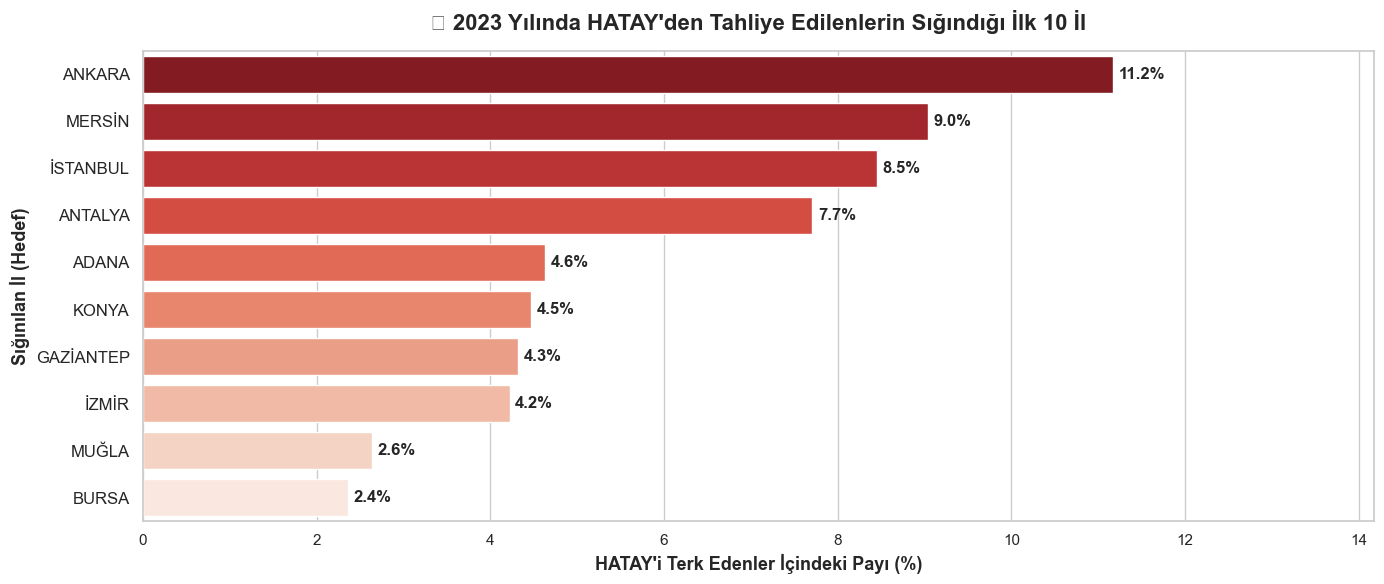

------------------------------------------------------------------------------------------------------------------------


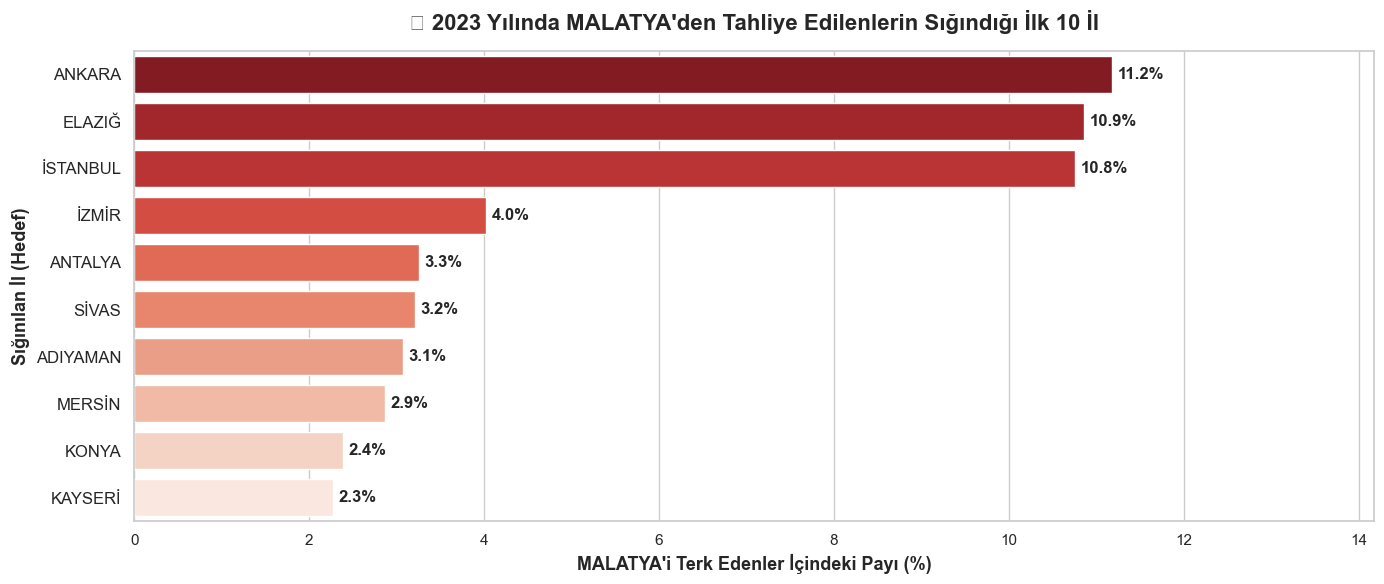

------------------------------------------------------------------------------------------------------------------------


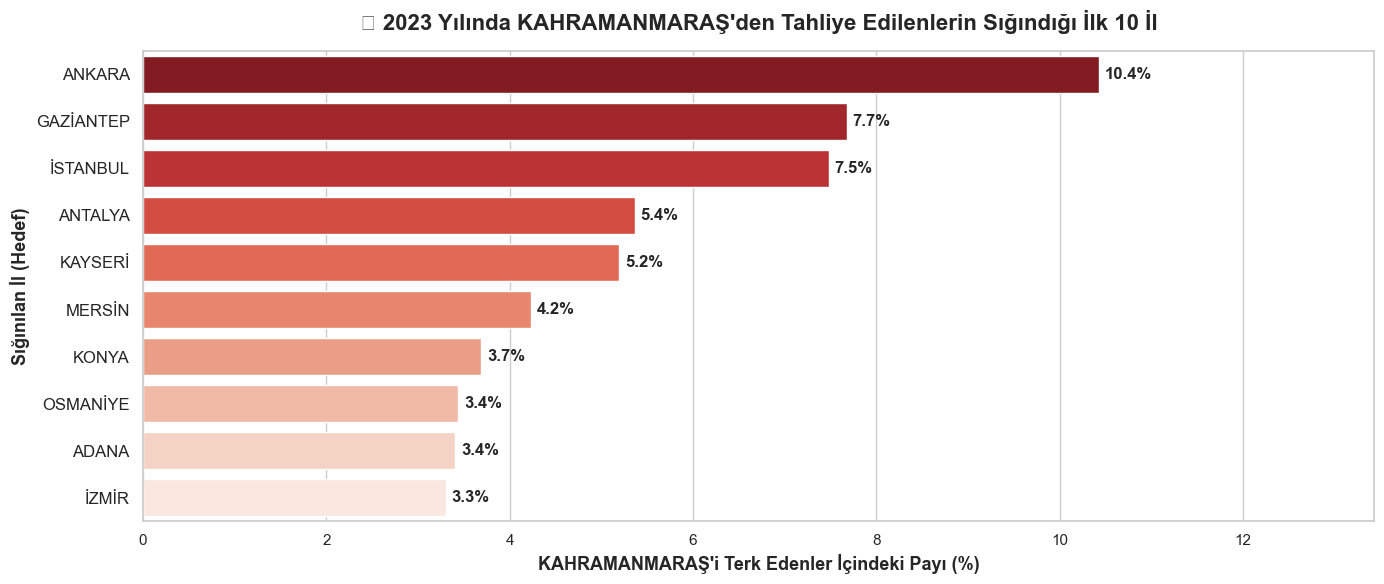

------------------------------------------------------------------------------------------------------------------------


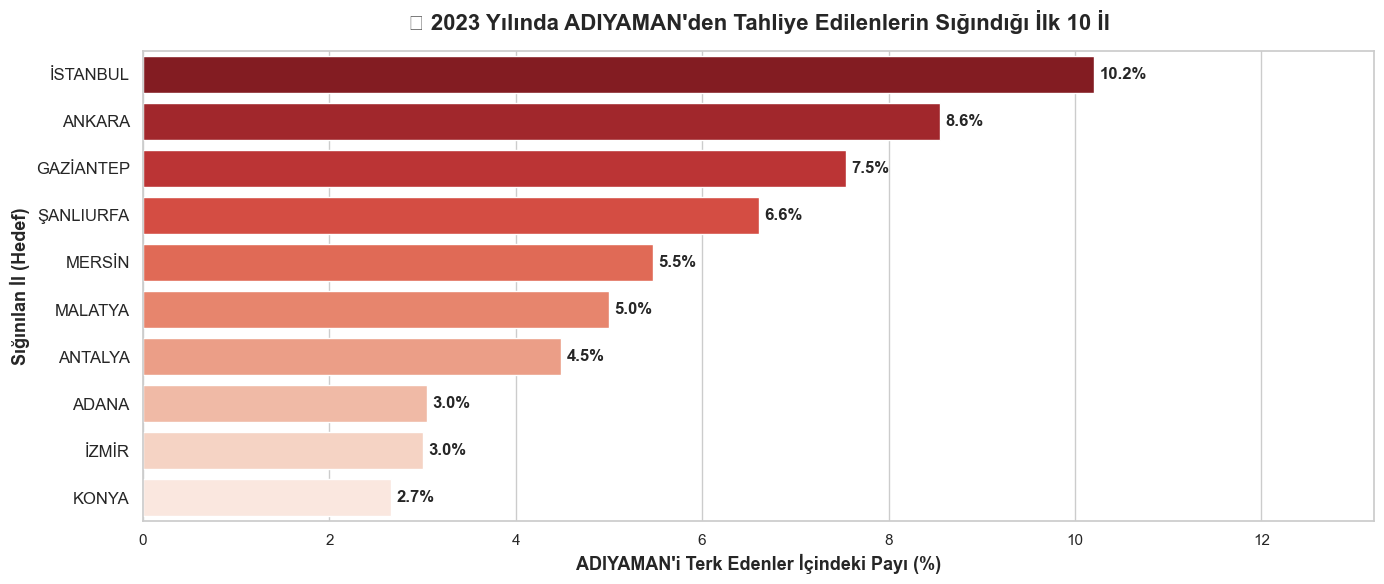

------------------------------------------------------------------------------------------------------------------------


In [37]:
# 17. Deprem Yılı (2023) Tahliye Rotaları: İnsanlar Nereye Sığındı?
# Grafikte çizgisi en çok fırlayan 4 ilin 2023'teki göç hedeflerine bakalım.

en_agir_hasarli_iller = ['HATAY', 'MALATYA', 'KAHRAMANMARAŞ', 'ADIYAMAN']

# Veri setimizden sadece DEPREM YILINI (2023) filtreleyelim
df_2023 = df[df['yil'] == 2023].copy()

for sehir in en_agir_hasarli_iller:
    # Bu şehirden (Örn: Hatay) 2023 yılında çıkan TOPLAM insan sayısı
    toplam_giden = df_2023[df_2023['goc_veren_il_adi'] == sehir]['aldigi_goc'].sum()
    
    # Gittikleri yerler
    hedef_iller = df_2023[df_2023['goc_veren_il_adi'] == sehir].copy()
    
    # Oranları hesaplayalım (Giden Kişi / Toplam Giden Kişi)
    hedef_iller['yuzde'] = (hedef_iller['aldigi_goc'] / toplam_giden) * 100
    
    # En çok göç alan ilk 10 ili (Sığınılan yerleri) seçelim
    hedef_top10 = hedef_iller.sort_values(by='yuzde', ascending=False).head(10)
    
    plt.figure(figsize=(14, 6))
    
    # Dramatik yapısına uygun olarak Koyu Kırmızıdan açığa doğru (Reds_r) bir tema kullanalım
    grafik = sns.barplot(data=hedef_top10, x='yuzde', y='goc_alan_il_adi', palette='Reds_r')
    
    # Barların uçlarına yüzdeleri yazdıralım
    for i in grafik.containers:
        grafik.bar_label(i, fmt='%.1f%%', padding=4, fontsize=12, fontweight='bold')
        
    plt.title(f'🖤 2023 Yılında {sehir}\'den Tahliye Edilenlerin Sığındığı İlk 10 İl', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel(f'{sehir}\'i Terk Edenler İçindeki Payı (%)', fontsize=13, fontweight='bold')
    plt.ylabel('Sığınılan İl (Hedef)', fontsize=13, fontweight='bold')
    plt.yticks(fontsize=12)
    
    # Yazıların grafiğin dışına taşmaması için X ekseni limitini biraz esnetelim
    plt.xlim(0, hedef_top10['yuzde'].max() + 3)
    
    plt.tight_layout()
    plt.show()
    print("-" * 120)


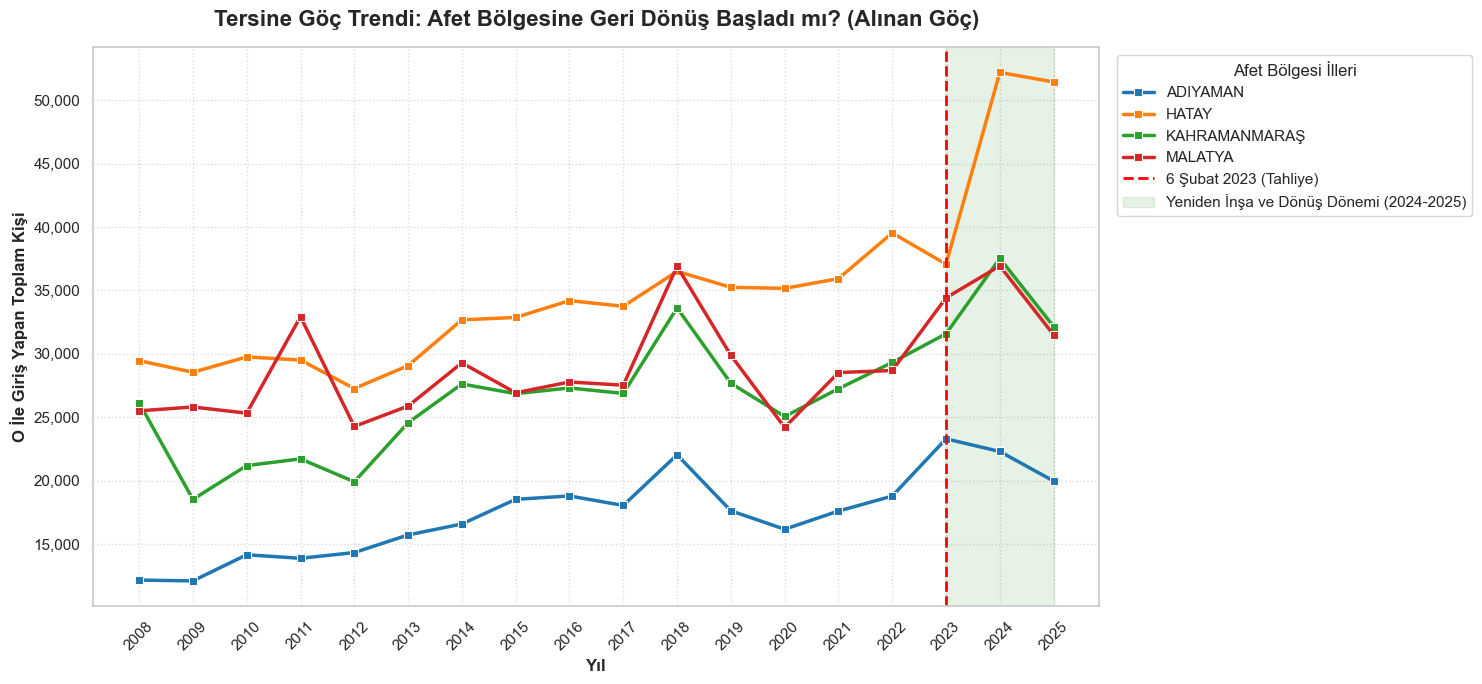

In [38]:
# 18. Tersine Göç Analizi: Depremzedeler Evlerine Döndü mü?
# En ağır hasarlı 4 ilin yıllar bazında ALDIĞI (goc_alan_il_adi) göçü çizelim.

en_agir_hasarli_iller = ['HATAY', 'MALATYA', 'KAHRAMANMARAŞ', 'ADIYAMAN']

# df_tersine için veri setinden bu 4 ili Hedef (Alan İl) olarak filtreleyelim
df_tersine = df[df['goc_alan_il_adi'].isin(en_agir_hasarli_iller)].copy()

# Yıllara ve İllere göre gruplayıp o yıl şehre giriş yapan insan sayısını bulalım
tersine_goc_trendi = df_tersine.groupby(['yil', 'goc_alan_il_adi'])['aldigi_goc'].sum().reset_index()

plt.figure(figsize=(15, 7))

# Çizgi grafiğimizi oluşturalım (marker='s' kare şeklinde noktalar atar)
sns.lineplot(data=tersine_goc_trendi, x='yil', y='aldigi_goc', hue='goc_alan_il_adi', 
             marker='s', linewidth=2.5, palette='tab10')

# Deprem yılını kırmızı çizgiyle gösterelim
plt.axvline(x=2023, color='red', linestyle='--', linewidth=2, label='6 Şubat 2023 (Tahliye)')

# 2023 sonrasını (2024-2025) grafikte hafif yeşil bir arka planla vurgulayalım (Dönüş Bölgesi)
plt.axvspan(2023, 2025, color='green', alpha=0.1, label='Yeniden İnşa ve Dönüş Dönemi (2024-2025)')

plt.title('Tersine Göç Trendi: Afet Bölgesine Geri Dönüş Başladı mı? (Alınan Göç)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Yıl', fontsize=12, fontweight='bold')
plt.ylabel('O İle Giriş Yapan Toplam Kişi', fontsize=12, fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.legend(title='Afet Bölgesi İlleri', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

yillar = sorted(df['yil'].dropna().unique())
plt.xticks(yillar, rotation=45)

plt.tight_layout()
plt.show()

### 💡 Analiz Çıkarımı: Depremzedeler Döndü mü?
Çizgi grafiğindeki hareketlilik bize **"Tersine Göçün"** (Yani depremzedelerin memleketlerine dönüşünün veya yeniden inşa için bölgeye gidişlerin) **2024 yılında zirve yaptığını** gösteriyor. 

* **2023 (Kırmızı Çizgi):** Deprem yılı. İnsanlar can havliyle şehri terk ettikleri için o yıl şehre giriş yapan (geri dönen) insan sayısı çok düşük.
* **2024 (Yeşil Alanın Başı):** Hatay, Maraş ve Malatya çizgileri **tarihi bir zirveye** fırlıyor. Bu, 2023'te giden insanların; enkazın kalkması, konteyner/prefabrik kentlerin kurulması ve ticari hayatın kısmen başlamasıyla **2024 yılında memleketlerine topluca geri döndüğünün** veriyle kanıtlanmış halidir.
* **2025:** Dönüş dalgası hız keserek yavaş yavaş normal sirkülasyona dönme eğilimine girmiş.

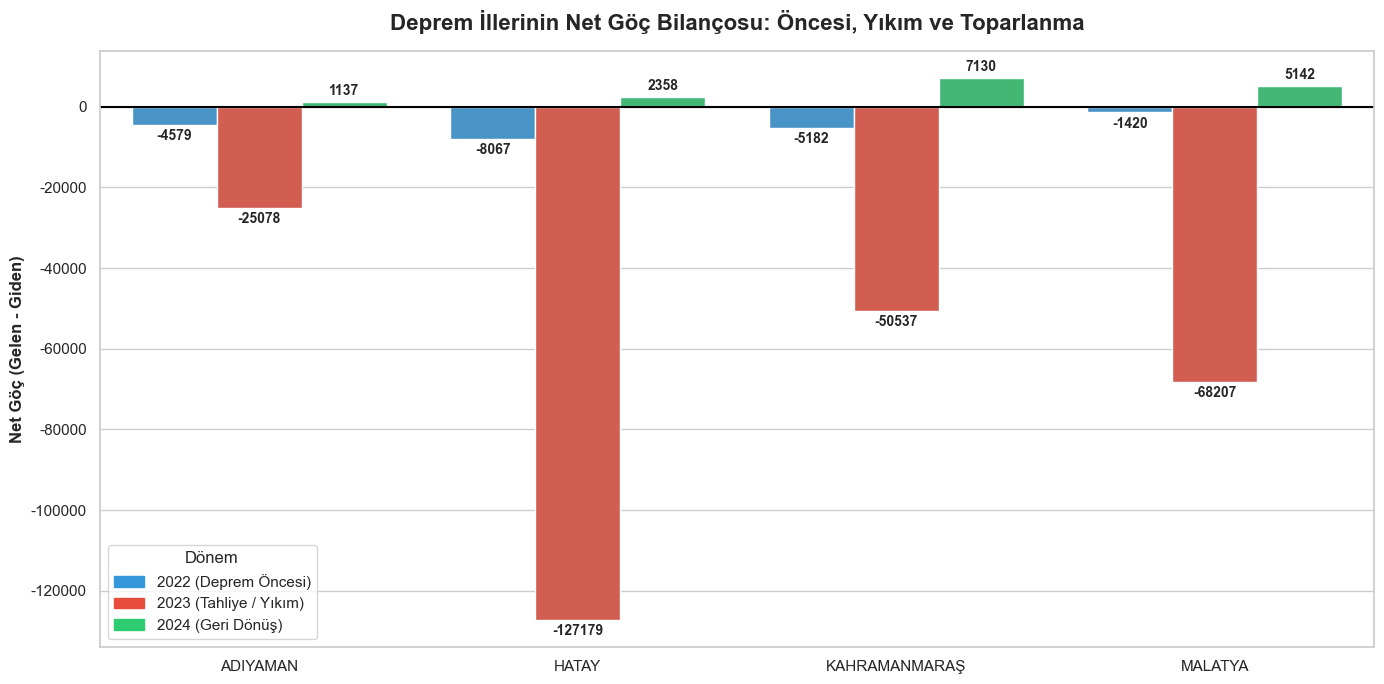

In [39]:
import matplotlib.patches as mpatches

# 19. Daha Basit Bir Bakış: Deprem İllerinin "Net Göç" Bilançosu
en_agir_hasarli_iller = ['HATAY', 'MALATYA', 'KAHRAMANMARAŞ', 'ADIYAMAN']
yillar = [2022, 2023, 2024]

# Gelenleri ve Gidenleri yıllara göre toplayalım
gelen = df[df['goc_alan_il_adi'].isin(en_agir_hasarli_iller) & df['yil'].isin(yillar)].groupby(['yil', 'goc_alan_il_adi'])['aldigi_goc'].sum().reset_index()
giden = df[df['goc_veren_il_adi'].isin(en_agir_hasarli_iller) & df['yil'].isin(yillar)].groupby(['yil', 'goc_veren_il_adi'])['aldigi_goc'].sum().reset_index()

# İkisini birleştirip Net Göç'ü bulalım (Gelen - Giden)
net_goc = pd.merge(gelen, giden, left_on=['yil', 'goc_alan_il_adi'], right_on=['yil', 'goc_veren_il_adi'])
net_goc['Net Göç'] = net_goc['aldigi_goc_x'] - net_goc['aldigi_goc_y']
net_goc = net_goc.rename(columns={'goc_alan_il_adi': 'İl', 'yil': 'Yıl'})

plt.figure(figsize=(14, 7))
# 2022: Mavi, 2023: Kırmızı (Yıkım), 2024: Yeşil (Dönüş)
grafik = sns.barplot(data=net_goc, x='İl', y='Net Göç', hue='Yıl', palette=['#3498db', '#e74c3c', '#2ecc71'])

# Ortaya net bir sıfır (0) çizgisi çekelim
plt.axhline(0, color='black', linewidth=1.5)
plt.title('Deprem İllerinin Net Göç Bilançosu: Öncesi, Yıkım ve Toparlanma', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Net Göç (Gelen - Giden)', fontsize=12, fontweight='bold')
plt.xlabel('')

# Sayıları bar uçlarına yazdıralım
for container in grafik.containers:
    grafik.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')

# --- LEJANTI DÜZELTME KISMI ---
# Renk kutucuklarını (Patch) manuel ve çok daha belirgin şekilde oluşturalım
mavi_kutu = mpatches.Patch(color='#3498db', label='2022 (Deprem Öncesi)')
kirmizi_kutu = mpatches.Patch(color='#e74c3c', label='2023 (Tahliye / Yıkım)')
yesil_kutu = mpatches.Patch(color='#2ecc71', label='2024 (Geri Dönüş)')

# Hazırladığımız kutucukları lejanta verelim (Konumunu sol alta alalım ki barlarla çakışmasın)
plt.legend(handles=[mavi_kutu, kirmizi_kutu, yesil_kutu], title='Dönem', fontsize=11, loc='lower left')

plt.tight_layout()
plt.show()

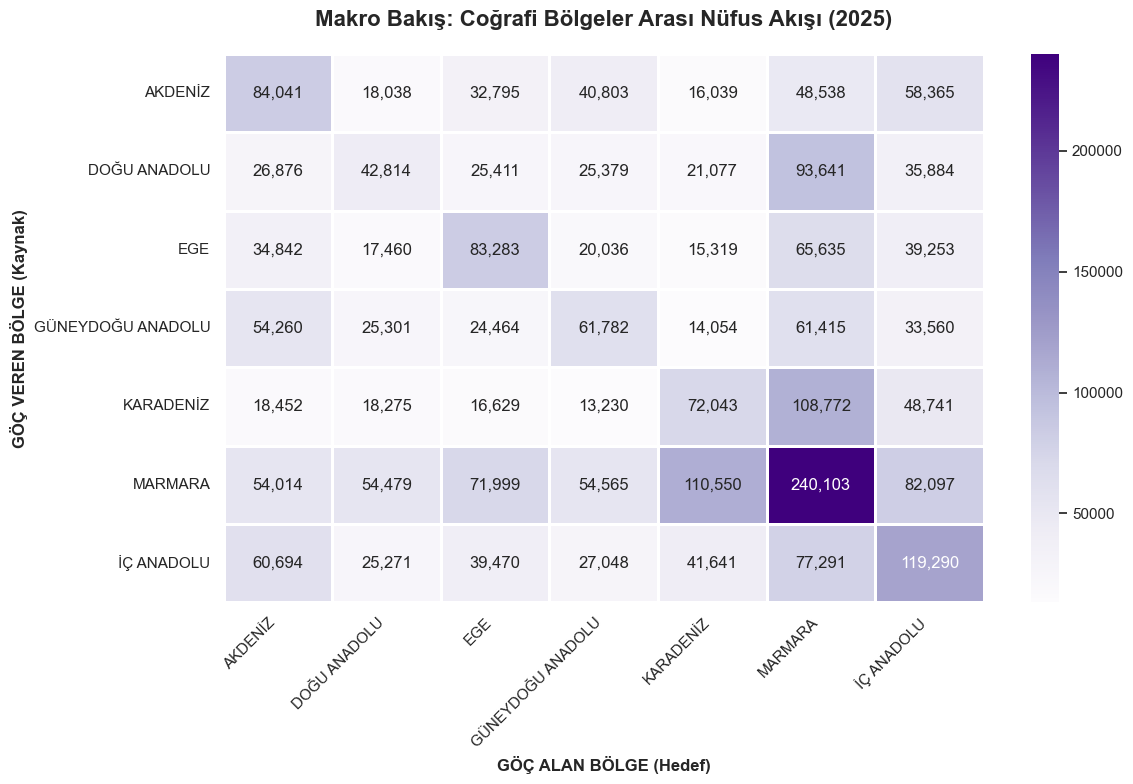

In [40]:
import numpy as np

# 20. Makro Bakış: Coğrafi Bölgeler Arası Nüfus Akışı
# 81 ili 7 Coğrafi Bölgeye ayırıp Türkiye'nin devasa göç haritasını (Isı Haritası) çizeceğiz.

bolge_sozlugu = {
    'MARMARA': ['İSTANBUL', 'EDİRNE', 'KIRKLARELİ', 'TEKİRDAĞ', 'ÇANAKKALE', 'KOCAELİ', 'YALOVA', 'SAKARYA', 'BİLECİK', 'BURSA', 'BALIKESİR'],
    'EGE': ['İZMİR', 'MANİSA', 'AYDIN', 'DENİZLİ', 'MUĞLA', 'AFYONKARAHİSAR', 'KÜTAHYA', 'UŞAK'],
    'AKDENİZ': ['ANTALYA', 'BURDUR', 'ISPARTA', 'MERSİN', 'ADANA', 'HATAY', 'OSMANİYE', 'KAHRAMANMARAŞ'],
    'İÇ ANADOLU': ['ANKARA', 'KONYA', 'KARAMAN', 'KIRIKKALE', 'KIRŞEHİR', 'YOZGAT', 'NEVŞEHİR', 'NİĞDE', 'AKSARAY', 'KAYSERİ', 'SİVAS', 'ESKİŞEHİR', 'ÇANKIRI'],
    'KARADENİZ': ['AMASYA', 'ARTVİN', 'BARTIN', 'BAYBURT', 'BOLU', 'ÇORUM', 'DÜZCE', 'GİRESUN', 'GÜMÜŞHANE', 'KARABÜK', 'KASTAMONU', 'ORDU', 'RİZE', 'SAMSUN', 'SİNOP', 'TOKAT', 'TRABZON', 'ZONGULDAK'],
    'DOĞU ANADOLU': ['AĞRI', 'ARDAHAN', 'BİNGÖL', 'BİTLİS', 'ELAZIĞ', 'ERZİNCAN', 'ERZURUM', 'HAKKARİ', 'IĞDIR', 'KARS', 'MALATYA', 'MUŞ', 'TUNCELİ', 'VAN'],
    'GÜNEYDOĞU ANADOLU': ['ADIYAMAN', 'BATMAN', 'DİYARBAKIR', 'GAZİANTEP', 'KİLİS', 'MARDİN', 'SİİRT', 'ŞANLIURFA', 'ŞIRNAK']
}

# Hızlı eşleştirme için ters sözlük (İl -> Bölge) yaratalım
il_to_bolge = {}
for bolge, iller in bolge_sozlugu.items():
    for il in iller:
        il_to_bolge[il] = bolge

# df_guncel üzerinden illeri bölgelerle eşleştirelim
df_bolge = df_guncel.copy()
df_bolge['goc_alan_bolge'] = df_bolge['goc_alan_il_adi'].map(il_to_bolge)
df_bolge['goc_veren_bolge'] = df_bolge['goc_veren_il_adi'].map(il_to_bolge)

# Bölgeden bölgeye toplam göçü pivotlayalım
bolge_matrisi = df_bolge.pivot_table(index='goc_veren_bolge', columns='goc_alan_bolge', values='aldigi_goc', aggfunc='sum')

# Çarpıcı bir etki için: Kendi bölgesi içindeki göçleri (Örn: Ege'den Ege'ye) sıfırlıyoruz. 
# Böylece sadece Bölgeler ARASI transferleri göreceğiz.
np.fill_diagonal(bolge_matrisi.values, 0)

plt.figure(figsize=(12, 8))

# fmt=",d" parametresi ile binlik sayı ayracı kullanıyoruz (Örn: 154,230)
# cmap='Purples' mor tonlarda şık bir yoğunluk haritası sunar
sns.heatmap(bolge_matrisi.astype(float), annot=True, fmt=",.0f", cmap='Purples', linewidths=1)

plt.title('Makro Bakış: Coğrafi Bölgeler Arası Nüfus Akışı (2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('GÖÇ ALAN BÖLGE (Hedef)', fontsize=12, fontweight='bold')
plt.ylabel('GÖÇ VEREN BÖLGE (Kaynak)', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

### 💡 Makro Analiz Çıkarımı: Türkiye'nin Nüfus Ekseni
Bölgeler arası devasa göç akışını gösteren bu ısı haritasına baktığımızda şu 3 net sosyolojik gerçeği görüyoruz:

1. **Marmara'nın "Kara Delik" Etkisi:** Haritadaki en koyu alanların  hedef sütununda toplandığını görüyoruz. **Karadeniz'den (108.772 kişi)** ve **Doğu Anadolu'dan (93.641 kişi)** kopan insanların ana hedefi açık ara Marmara Bölgesi olmuş. Türkiye'nin doğusu ve kuzeyi adeta Marmara'ya akmaktadır.
2. **Büyükşehirden Kaçış (Tersine Göç ve Sahile İniş):** nın göç verdiği satıra baktığımızda çok çarpıcı bir detay göze çarpıyor: Marmara, **Karadeniz'e 110.550**, **Ege'ye ise 71.999** kişi göndermiş. Bu durum; emeklilikte memlekete (Karadeniz'e) dönüşlerin ve İstanbul'un stresinden/pahalılığından kaçıp Ege sahillerine yerleşme (beyaz yaka) trendinin devasa boyutlara ulaştığının rakamsal kanıtıdır.
3. **Kendi Çöplüğünde Kalma (Bölge İçi Sirkülasyon):** Tablodaki çapraz eksen (Marmara'dan Marmara'ya 240 bin, İç Anadolu'dan İç Anadolu'ya 119 bin kişi) en yüksek sayıları barındırıyor. Bu bize şunu söylüyor: İnsanlar göç ederken ağırlıklı olarak **kendi kültürel coğrafyalarından ve iklimlerinden çok uzaklaşmadan**, hemen yanlarındaki veya bölgelerindeki en büyük cazibe merkezine (Örn: Yozgat'tan Ankara'ya, Aydın'dan İzmir'e) geçmeyi tercih ediyor.

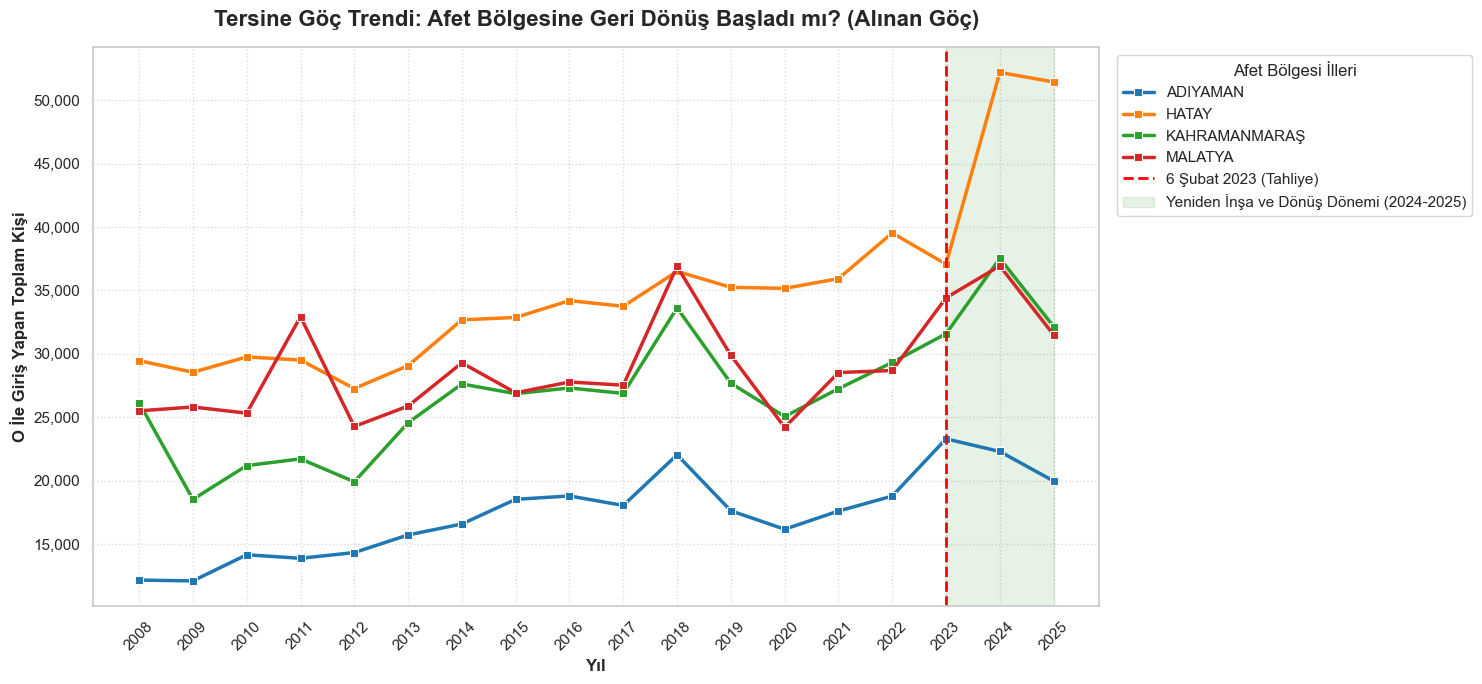

In [41]:
# 18. Tersine Göç Analizi: Depremzedeler Evlerine Döndü mü?
# En ağır hasarlı 4 ilin yıllar bazında ALDIĞI (goc_alan_il_adi) göçü çizelim.

en_agir_hasarli_iller = ['HATAY', 'MALATYA', 'KAHRAMANMARAŞ', 'ADIYAMAN']

# df_tersine için veri setinden bu 4 ili Hedef (Alan İl) olarak filtreleyelim
df_tersine = df[df['goc_alan_il_adi'].isin(en_agir_hasarli_iller)].copy()

# Yıllara ve İllere göre gruplayıp o yıl şehre giriş yapan insan sayısını bulalım
tersine_goc_trendi = df_tersine.groupby(['yil', 'goc_alan_il_adi'])['aldigi_goc'].sum().reset_index()

plt.figure(figsize=(15, 7))

# Çizgi grafiğimizi oluşturalım (marker='s' kare şeklinde noktalar atar)
sns.lineplot(data=tersine_goc_trendi, x='yil', y='aldigi_goc', hue='goc_alan_il_adi', 
             marker='s', linewidth=2.5, palette='tab10')

# Deprem yılını kırmızı çizgiyle gösterelim
plt.axvline(x=2023, color='red', linestyle='--', linewidth=2, label='6 Şubat 2023 (Tahliye)')

# 2023 sonrasını (2024-2025) grafikte hafif yeşil bir arka planla vurgulayalım (Dönüş Bölgesi)
plt.axvspan(2023, 2025, color='green', alpha=0.1, label='Yeniden İnşa ve Dönüş Dönemi (2024-2025)')

plt.title('Tersine Göç Trendi: Afet Bölgesine Geri Dönüş Başladı mı? (Alınan Göç)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Yıl', fontsize=12, fontweight='bold')
plt.ylabel('O İle Giriş Yapan Toplam Kişi', fontsize=12, fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.legend(title='Afet Bölgesi İlleri', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

yillar = sorted(df['yil'].dropna().unique())
plt.xticks(yillar, rotation=45)

plt.tight_layout()
plt.show()

### 💡 Analiz Çıkarımı: Depremzedeler Döndü mü?
Çizgi grafiğindeki hareketlilik bize **"Tersine Göçün"** (Yani depremzedelerin memleketlerine dönüşünün veya yeniden inşa için bölgeye gidişlerin) **2024 yılında zirve yaptığını** gösteriyor. 

* **2023 (Kırmızı Çizgi):** Deprem yılı. İnsanlar can havliyle şehri terk ettikleri için o yıl şehre giriş yapan (geri dönen) insan sayısı çok düşük.
* **2024 (Yeşil Alanın Başı):** Hatay, Maraş ve Malatya çizgileri **tarihi bir zirveye** fırlıyor. Bu, 2023'te giden insanların; enkazın kalkması, konteyner/prefabrik kentlerin kurulması ve ticari hayatın kısmen başlamasıyla **2024 yılında memleketlerine topluca geri döndüğünün** veriyle kanıtlanmış halidir.
* **2025:** Dönüş dalgası hız keserek yavaş yavaş normal sirkülasyona dönme eğilimine girmiş.

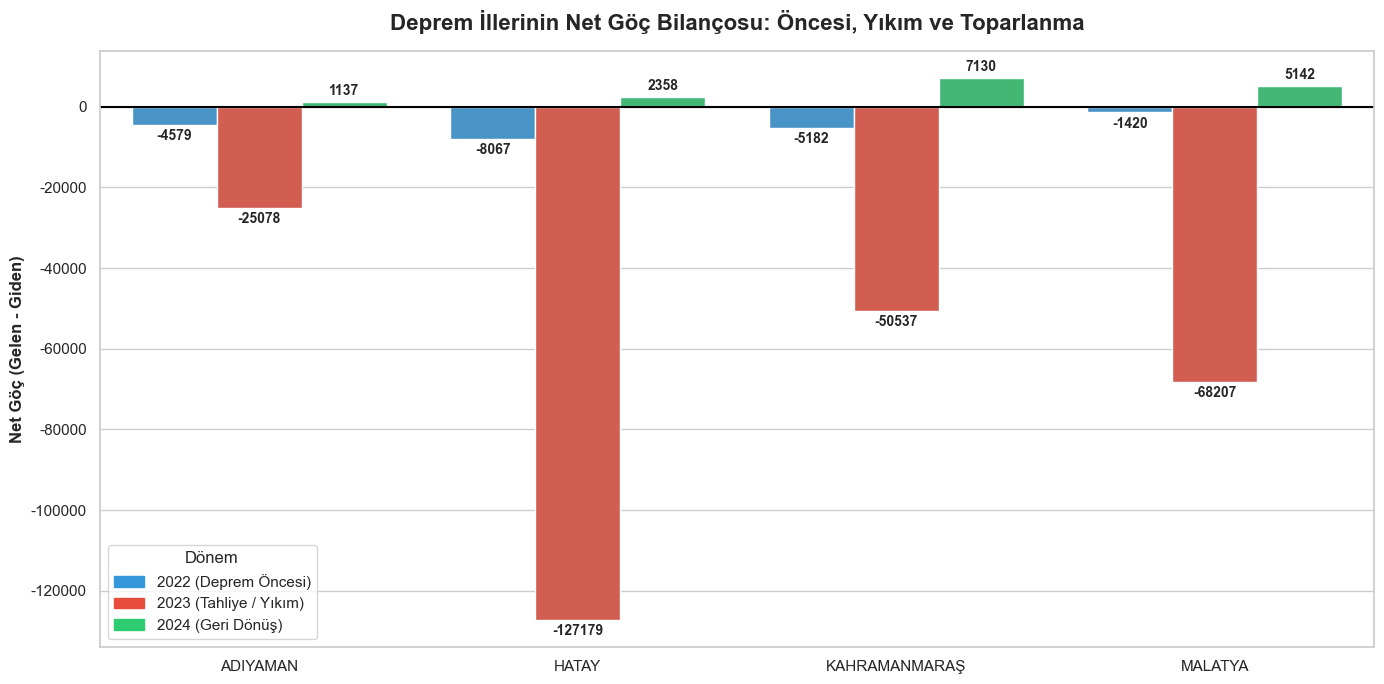

In [42]:
import matplotlib.patches as mpatches

# 19. Daha Basit Bir Bakış: Deprem İllerinin "Net Göç" Bilançosu
en_agir_hasarli_iller = ['HATAY', 'MALATYA', 'KAHRAMANMARAŞ', 'ADIYAMAN']
yillar = [2022, 2023, 2024]

# Gelenleri ve Gidenleri yıllara göre toplayalım
gelen = df[df['goc_alan_il_adi'].isin(en_agir_hasarli_iller) & df['yil'].isin(yillar)].groupby(['yil', 'goc_alan_il_adi'])['aldigi_goc'].sum().reset_index()
giden = df[df['goc_veren_il_adi'].isin(en_agir_hasarli_iller) & df['yil'].isin(yillar)].groupby(['yil', 'goc_veren_il_adi'])['aldigi_goc'].sum().reset_index()

# İkisini birleştirip Net Göç'ü bulalım (Gelen - Giden)
net_goc = pd.merge(gelen, giden, left_on=['yil', 'goc_alan_il_adi'], right_on=['yil', 'goc_veren_il_adi'])
net_goc['Net Göç'] = net_goc['aldigi_goc_x'] - net_goc['aldigi_goc_y']
net_goc = net_goc.rename(columns={'goc_alan_il_adi': 'İl', 'yil': 'Yıl'})

plt.figure(figsize=(14, 7))
# 2022: Mavi, 2023: Kırmızı (Yıkım), 2024: Yeşil (Dönüş)
grafik = sns.barplot(data=net_goc, x='İl', y='Net Göç', hue='Yıl', palette=['#3498db', '#e74c3c', '#2ecc71'])

# Ortaya net bir sıfır (0) çizgisi çekelim
plt.axhline(0, color='black', linewidth=1.5)
plt.title('Deprem İllerinin Net Göç Bilançosu: Öncesi, Yıkım ve Toparlanma', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Net Göç (Gelen - Giden)', fontsize=12, fontweight='bold')
plt.xlabel('')

# Sayıları bar uçlarına yazdıralım
for container in grafik.containers:
    grafik.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')

# --- LEJANTI DÜZELTME KISMI ---
# Renk kutucuklarını (Patch) manuel ve çok daha belirgin şekilde oluşturalım
mavi_kutu = mpatches.Patch(color='#3498db', label='2022 (Deprem Öncesi)')
kirmizi_kutu = mpatches.Patch(color='#e74c3c', label='2023 (Tahliye / Yıkım)')
yesil_kutu = mpatches.Patch(color='#2ecc71', label='2024 (Geri Dönüş)')

# Hazırladığımız kutucukları lejanta verelim (Konumunu sol alta alalım ki barlarla çakışmasın)
plt.legend(handles=[mavi_kutu, kirmizi_kutu, yesil_kutu], title='Dönem', fontsize=11, loc='lower left')

plt.tight_layout()
plt.show()

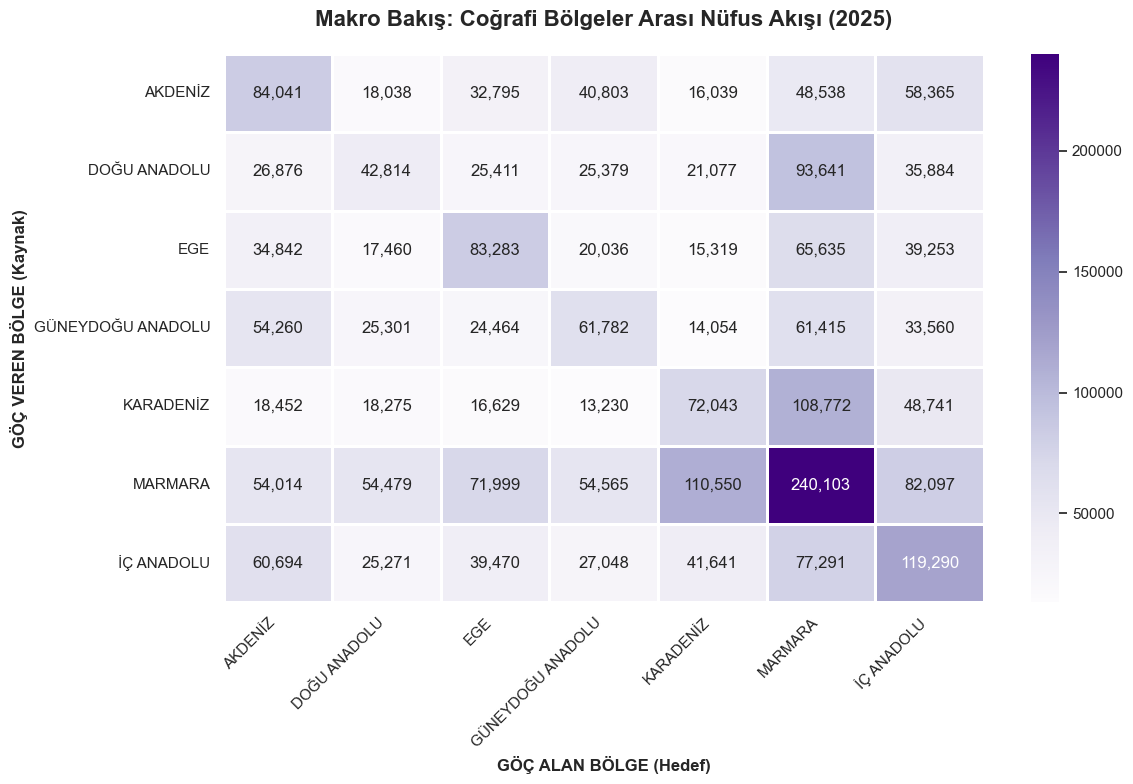

In [43]:
import numpy as np

# 20. Makro Bakış: Coğrafi Bölgeler Arası Nüfus Akışı
# 81 ili 7 Coğrafi Bölgeye ayırıp Türkiye'nin devasa göç haritasını (Isı Haritası) çizeceğiz.

bolge_sozlugu = {
    'MARMARA': ['İSTANBUL', 'EDİRNE', 'KIRKLARELİ', 'TEKİRDAĞ', 'ÇANAKKALE', 'KOCAELİ', 'YALOVA', 'SAKARYA', 'BİLECİK', 'BURSA', 'BALIKESİR'],
    'EGE': ['İZMİR', 'MANİSA', 'AYDIN', 'DENİZLİ', 'MUĞLA', 'AFYONKARAHİSAR', 'KÜTAHYA', 'UŞAK'],
    'AKDENİZ': ['ANTALYA', 'BURDUR', 'ISPARTA', 'MERSİN', 'ADANA', 'HATAY', 'OSMANİYE', 'KAHRAMANMARAŞ'],
    'İÇ ANADOLU': ['ANKARA', 'KONYA', 'KARAMAN', 'KIRIKKALE', 'KIRŞEHİR', 'YOZGAT', 'NEVŞEHİR', 'NİĞDE', 'AKSARAY', 'KAYSERİ', 'SİVAS', 'ESKİŞEHİR', 'ÇANKIRI'],
    'KARADENİZ': ['AMASYA', 'ARTVİN', 'BARTIN', 'BAYBURT', 'BOLU', 'ÇORUM', 'DÜZCE', 'GİRESUN', 'GÜMÜŞHANE', 'KARABÜK', 'KASTAMONU', 'ORDU', 'RİZE', 'SAMSUN', 'SİNOP', 'TOKAT', 'TRABZON', 'ZONGULDAK'],
    'DOĞU ANADOLU': ['AĞRI', 'ARDAHAN', 'BİNGÖL', 'BİTLİS', 'ELAZIĞ', 'ERZİNCAN', 'ERZURUM', 'HAKKARİ', 'IĞDIR', 'KARS', 'MALATYA', 'MUŞ', 'TUNCELİ', 'VAN'],
    'GÜNEYDOĞU ANADOLU': ['ADIYAMAN', 'BATMAN', 'DİYARBAKIR', 'GAZİANTEP', 'KİLİS', 'MARDİN', 'SİİRT', 'ŞANLIURFA', 'ŞIRNAK']
}

# Hızlı eşleştirme için ters sözlük (İl -> Bölge) yaratalım
il_to_bolge = {}
for bolge, iller in bolge_sozlugu.items():
    for il in iller:
        il_to_bolge[il] = bolge

# df_guncel üzerinden illeri bölgelerle eşleştirelim
df_bolge = df_guncel.copy()
df_bolge['goc_alan_bolge'] = df_bolge['goc_alan_il_adi'].map(il_to_bolge)
df_bolge['goc_veren_bolge'] = df_bolge['goc_veren_il_adi'].map(il_to_bolge)

# Bölgeden bölgeye toplam göçü pivotlayalım
bolge_matrisi = df_bolge.pivot_table(index='goc_veren_bolge', columns='goc_alan_bolge', values='aldigi_goc', aggfunc='sum')

# Çarpıcı bir etki için: Kendi bölgesi içindeki göçleri (Örn: Ege'den Ege'ye) sıfırlıyoruz. 
# Böylece sadece Bölgeler ARASI transferleri göreceğiz.
np.fill_diagonal(bolge_matrisi.values, 0)

plt.figure(figsize=(12, 8))

# fmt=",d" parametresi ile binlik sayı ayracı kullanıyoruz (Örn: 154,230)
# cmap='Purples' mor tonlarda şık bir yoğunluk haritası sunar
sns.heatmap(bolge_matrisi.astype(float), annot=True, fmt=",.0f", cmap='Purples', linewidths=1)

plt.title('Makro Bakış: Coğrafi Bölgeler Arası Nüfus Akışı (2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('GÖÇ ALAN BÖLGE (Hedef)', fontsize=12, fontweight='bold')
plt.ylabel('GÖÇ VEREN BÖLGE (Kaynak)', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

### 💡 Makro Analiz Çıkarımı: Türkiye'nin Nüfus Ekseni
Bölgeler arası devasa göç akışını gösteren bu ısı haritasına baktığımızda şu 3 net sosyolojik gerçeği görüyoruz:

1. **Marmara'nın "Kara Delik" Etkisi:** Haritadaki en koyu alanların `MARMARA` hedef sütununda toplandığını görüyoruz. **Karadeniz'den (108.772 kişi)** ve **Doğu Anadolu'dan (93.641 kişi)** kopan insanların ana hedefi açık ara Marmara Bölgesi olmuş. Türkiye'nin doğusu ve kuzeyi adeta Marmara'ya akmaktadır.
2. **Büyükşehirden Kaçış (Tersine Göç ve Sahile İniş):** `MARMARA`nın göç verdiği satıra baktığımızda çok çarpıcı bir detay göze çarpıyor: Marmara, **Karadeniz'e 110.550**, **Ege'ye ise 71.999** kişi göndermiş. Bu durum; emeklilikte memlekete (Karadeniz'e) dönüşlerin ve İstanbul'un stresinden/pahalılığından kaçıp Ege sahillerine yerleşme (beyaz yaka) trendinin devasa boyutlara ulaştığının rakamsal kanıtıdır.
3. **Kendi Çöplüğünde Kalma (Bölge İçi Sirkülasyon):** Tablodaki çapraz eksen (Marmara'dan Marmara'ya 240 bin, İç Anadolu'dan İç Anadolu'ya 119 bin kişi) en yüksek sayıları barındırıyor. Bu bize şunu söylüyor: İnsanlar göç ederken ağırlıklı olarak **kendi kültürel coğrafyalarından ve iklimlerinden çok uzaklaşmadan**, hemen yanlarındaki veya bölgelerindeki en büyük cazibe merkezine (Örn: Yozgat'tan Ankara'ya, Aydın'dan İzmir'e) geçmeyi tercih ediyor.

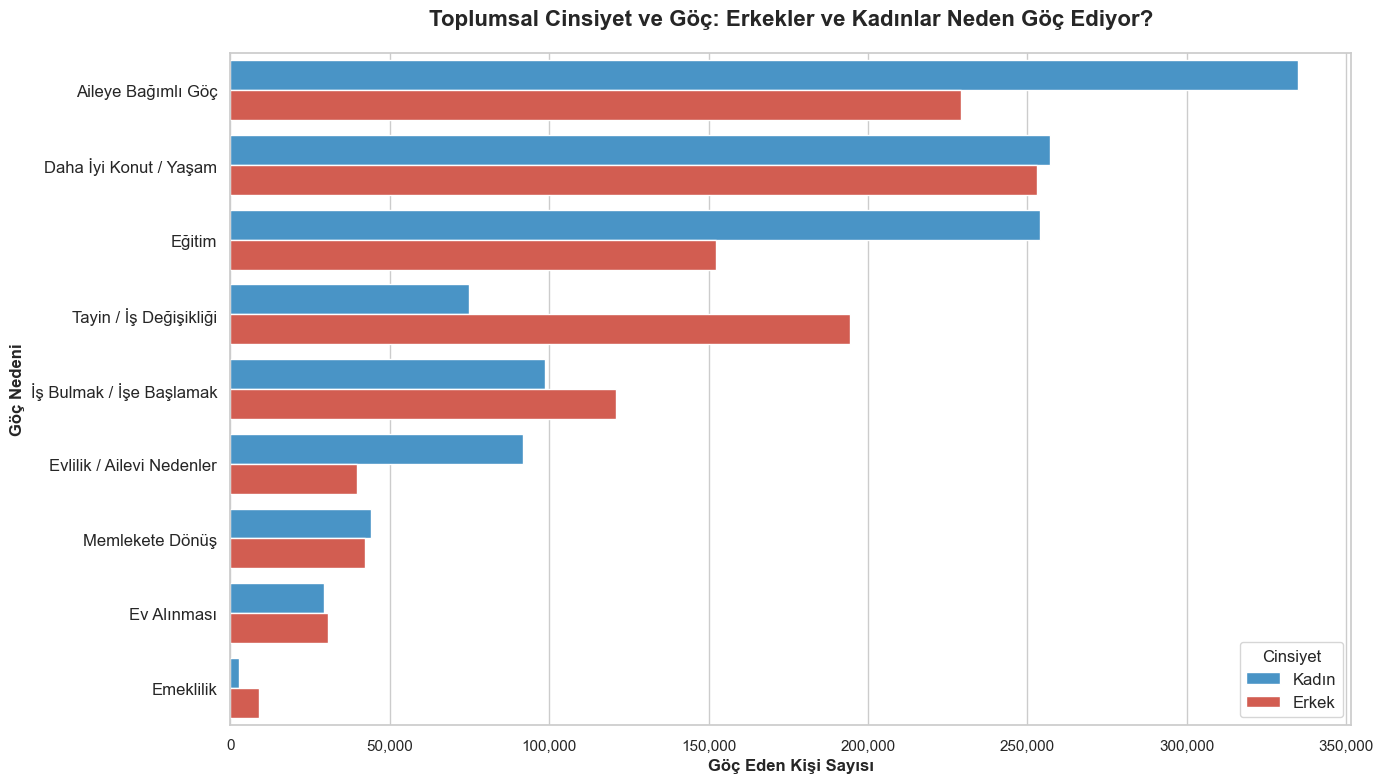

In [44]:
# 21. Toplumsal Cinsiyet ve Göç: Kadınlar ve Erkekler NEDEN Göç Ediyor?
df_cinsiyet = pd.read_csv(PROCESSED_DATA_DIR / 'yas_cinsiyet_neden.csv')

# Excel yapısındaki boş yaş gruplarını üsttekiyle dolduralım (Forward Fill)
df_cinsiyet['Yaş grubu Age group'] = df_cinsiyet['Yaş grubu Age group'].ffill()

# Sadece "Toplam" yaş grubundaki Kadın ve Erkek satırlarını filtreleyelim
df_cinsiyet = df_cinsiyet[df_cinsiyet['Yaş grubu Age group'].astype(str).str.contains('Toplam') & 
                          (df_cinsiyet['Cinsiyet Sex'].isin(['Erkek-Male', 'Kadın-Female']))].copy()

# Karmaşık kolon isimlerini temizleyelim
neden_kolonlari = {
    'Tayin / iş değişikliği Assignation / change of job': 'Tayin / İş Değişikliği',
    'İşe  başlamak / iş bulmak Starting / finding a job': 'İş Bulmak / İşe Başlamak',
    'Eğitim Education': 'Eğitim',
    'Medeni durum değişikliği / ailevi nedenler  Change of marital status / family-related reasons': 'Evlilik / Ailevi Nedenler',
    'Daha iyi konut  ve yaşam koşulları  Better  housing and  living conditions': 'Daha İyi Konut / Yaşam',
    'Hane / aile fertlerinden  birine bağımlı göç Migration related to any member of the household / family': 'Aileye Bağımlı Göç',
    'Aile yanına / memlekete geri dönme(1)  Returning to family home / hometown(1)': 'Memlekete Dönüş',
    'Ev alınması Buying a house': 'Ev Alınması',
    'Emeklilik Retirement': 'Emeklilik'
}

# İlgili kolonları seçip adlarını düzeltelim
df_cinsiyet_filtre = df_cinsiyet[['Cinsiyet Sex'] + list(neden_kolonlari.keys())].rename(columns=neden_kolonlari)

# Cinsiyet isimlerini sadeleştirelim
df_cinsiyet_filtre['Cinsiyet Sex'] = df_cinsiyet_filtre['Cinsiyet Sex'].replace({'Erkek-Male': 'Erkek', 'Kadın-Female': 'Kadın'})

# Verileri sayısal formata çevirelim
for col in neden_kolonlari.values():
    df_cinsiyet_filtre[col] = pd.to_numeric(df_cinsiyet_filtre[col], errors='coerce')

# Grafiği çizebilmek için veriyi "Melt" komutuyla Uzun Formata (Long Format) çevirelim
df_cinsiyet_melt = df_cinsiyet_filtre.melt(id_vars='Cinsiyet Sex', var_name='Neden', value_name='Kişi Sayısı')

# Sayılara göre büyükten küçüğe sıralayalım ki grafik güzel görünsün
df_cinsiyet_melt = df_cinsiyet_melt.sort_values(by='Kişi Sayısı', ascending=False)

plt.figure(figsize=(14, 8))
# Erkekler için Mavi, Kadınlar için Pembe/Kırmızı bir tema kullanalım
grafik = sns.barplot(data=df_cinsiyet_melt, x='Kişi Sayısı', y='Neden', hue='Cinsiyet Sex', palette=['#3498db', '#e74c3c'])

plt.title('Toplumsal Cinsiyet ve Göç: Erkekler ve Kadınlar Neden Göç Ediyor?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Göç Eden Kişi Sayısı', fontsize=12, fontweight='bold')
plt.ylabel('Göç Nedeni', fontsize=12, fontweight='bold')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.yticks(fontsize=12)

# Lejant ayarları
plt.legend(title='Cinsiyet', fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.show()


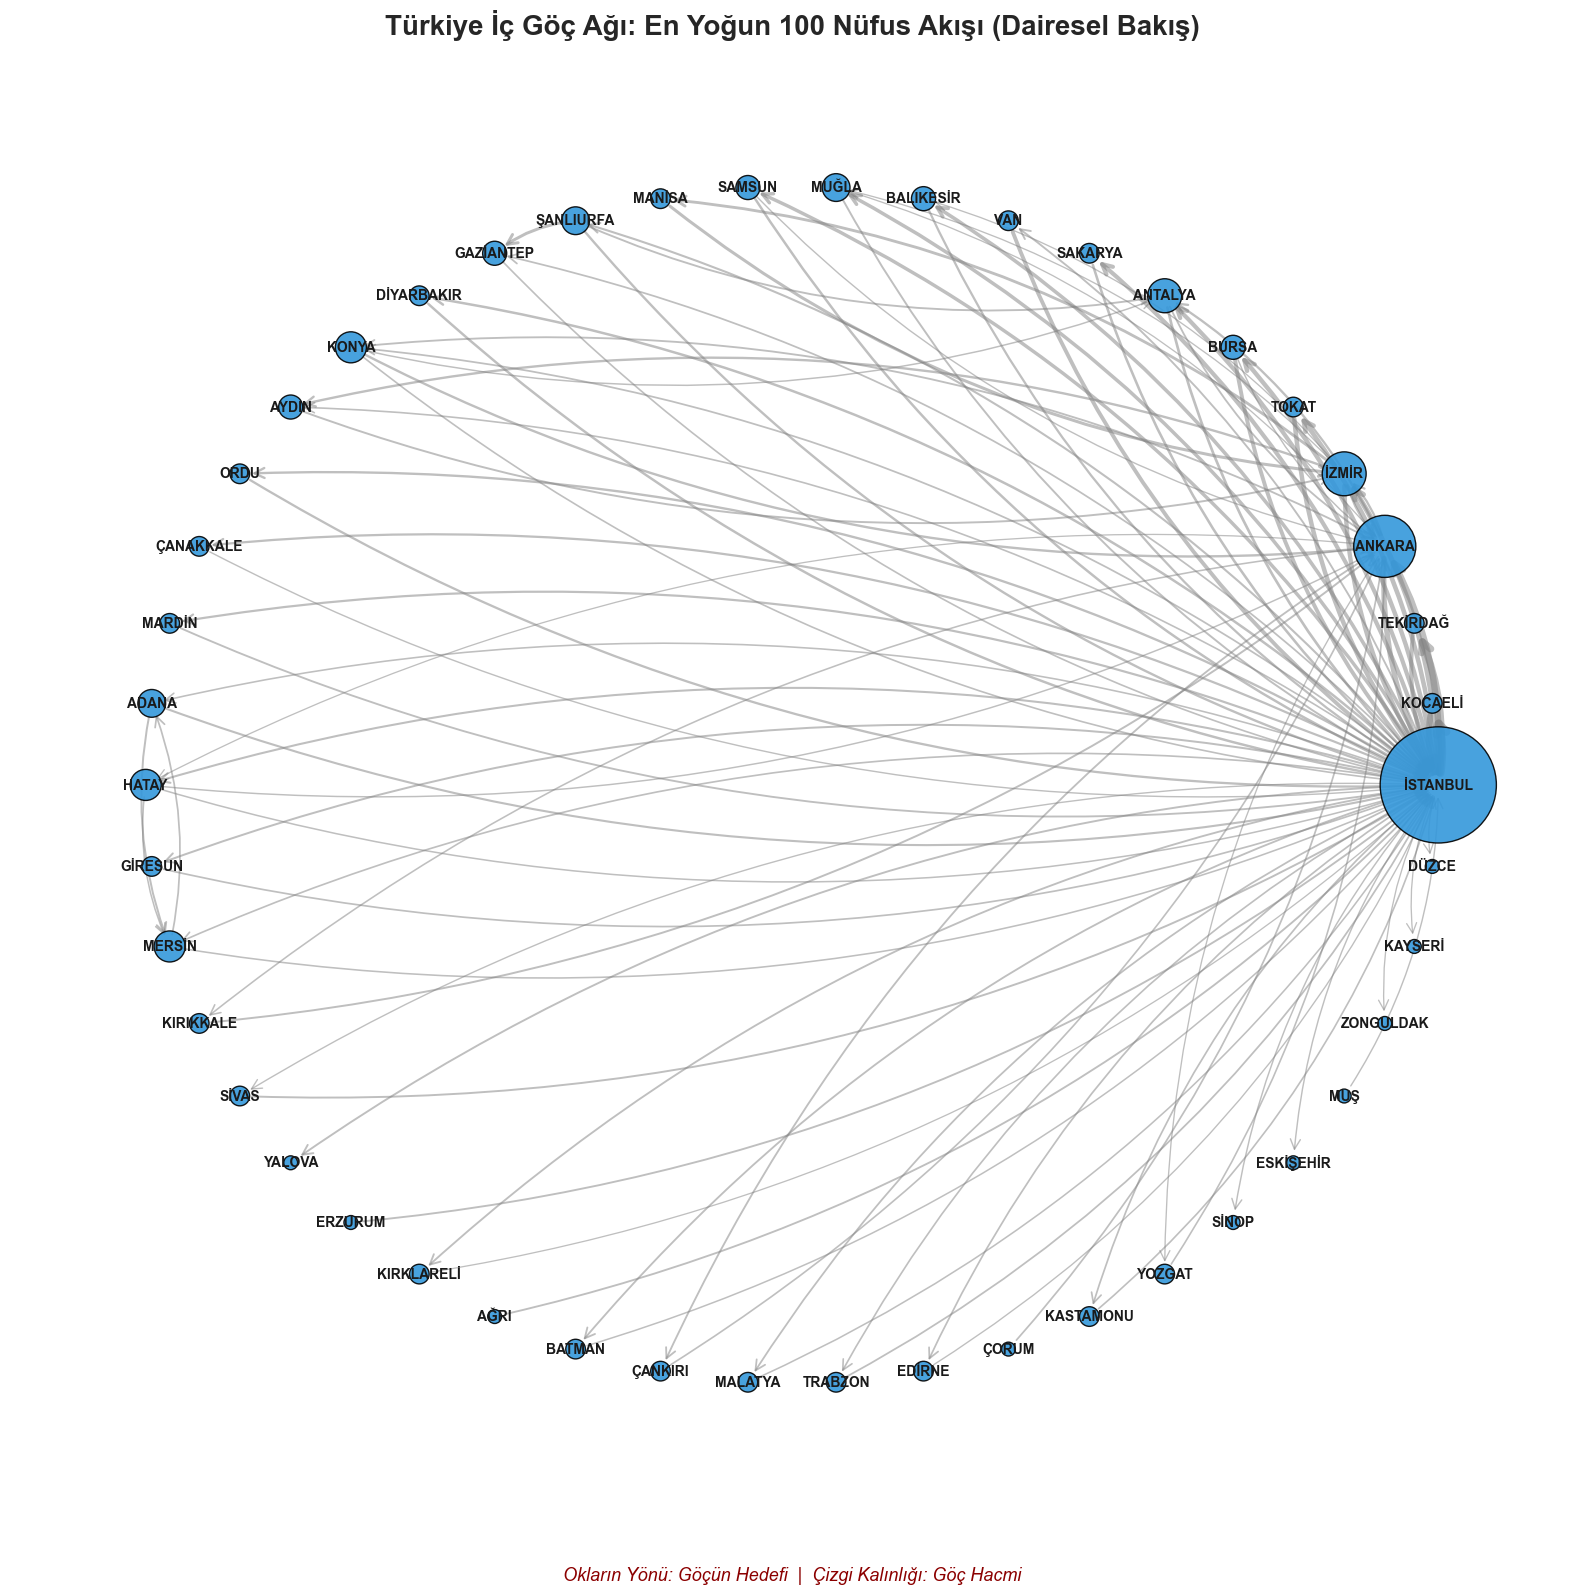

In [45]:
import networkx as nx

# 21. İleri Düzey Analitik: Türkiye'nin Göç Ağı Haritası (Dairesel Yerleşim)
top_100_akis = df_guncel.nlargest(100, 'aldigi_goc')

G = nx.DiGraph()

for _, row in top_100_akis.iterrows():
    kaynak = row['goc_veren_il_adi']
    hedef = row['goc_alan_il_adi']
    agirlik = row['aldigi_goc']
    G.add_edge(kaynak, hedef, weight=agirlik)

# Balon büyüklüklerini biraz daha küçültelim ki çemberde taşmasın
d_sizes = [G.degree(node) * 100 for node in G.nodes()]

# Grafiği tam kare (16x16) yapalım ki çember kusursuz dairesel olsun
plt.figure(figsize=(16, 16))

# --- ÇÖZÜM BURADA: Şehirleri Kara Delik yerine Çembere (Circular) diziyoruz ---
pos = nx.circular_layout(G)

# Çizgilerin kalınlıkları
edge_weights = [G[u][v]['weight'] / 4000 for u, v in G.edges()]

# Ağı Çizdirme
nx.draw_networkx_nodes(G, pos, node_size=d_sizes, node_color='#3498db', edgecolors='black', alpha=0.9)

# Çizgilerin kavisini (rad) biraz daha artırdık ki çemberin ortasından geçerken rahat okunsun
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color='gray', 
                       arrowsize=18, arrowstyle='->', connectionstyle="arc3,rad=0.15", alpha=0.5)

# Şehir isimlerini merkeze veya dışa doğru hizalamak için küçük bir ayar
# Fontu biraz küçülttük
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif', font_weight='bold')

plt.title('Türkiye İç Göç Ağı: En Yoğun 100 Nüfus Akışı (Dairesel Bakış)', fontsize=20, fontweight='bold', pad=20)
plt.axis('off')

plt.text(0.5, -0.05, 
         "Okların Yönü: Göçün Hedefi  |  Çizgi Kalınlığı: Göç Hacmi", 
         ha='center', fontsize=13, style='italic', transform=plt.gca().transAxes, color='darkred')

plt.tight_layout()
plt.show()
